# OLS to GPT
#### In 20 Steps

There is a popular idea that artificial intelligence is something categorically different from conventional statistics and that at some point a model crosses a threshold and becomes something new, something that thinks. This notebook argues that idea is wrong.

What follows is a single continuous thread. It begins with the simplest possible model: a line fit to a handful of points using ordinary least squares (OLS). It ends with the architecture behind GPT, the class of model that powers modern large language models. Each model between them implements only minor modifications or additions. At no point is there a clean break between statistics and AI. There is only a spectrum.

This matters for two reasons. First, it is useful as a learning exercise. Someone who genuinely understands linear regression already understands much of what makes a transformer work. The concepts are the same: a parametric model, a loss function, an optimizer that minimizes it, and a prediction on new data. Second, it is intellectually honest. The mystique surrounding modern AI systems is largely a product of scale and opacity, not of fundamentally new ideas. The core machinery, maximum likelihood estimation, gradient descent, and learned representations, has been in the statistical literature for decades.

The unifying goal throughout is **prediction**: given some inputs, what is the most probable output? From predicting a continuous value with least squares, to predicting the next character in a Shakespeare play with a stacked transformer, the model is always learning a mapping from inputs to outputs that generalises beyond the training data. The inputs get richer, the mappings get more complex, and the outputs get more expressive, but the logic never changes.

## Outline

| Step | Model | Target | Input | Estimator | Framework |
|------|-------|--------|-------|-----------|-----------|
| 0 | Univariate linear regression | Continuous | Continuous (p=1) | Least squares | NumPy |
| 1 | Multivariate linear regression | Continuous | Continuous (p>1) | Least squares | NumPy |
| 2 | Multivariate linear regression | Continuous | Continuous (p>1) | MLE + Newton's method | NumPy |
| 3 | Logistic regression | Binary | Continuous | MLE + Newton's method | NumPy |
| 4 | Logistic regression | Binary | Continuous | MLE + gradient descent | NumPy |
| 5 | Logistic regression | Binary | Continuous | MLE + gradient descent | PyTorch |
| 6 | Neural network — sigmoid hidden layer | Binary | Continuous | MLE + gradient descent | PyTorch |
| 7 | Neural network — ReLU hidden layer | Binary | Continuous | MLE + gradient descent | PyTorch |
| 8 | Neural network — multi-class classification | Multi-class | Continuous | MLE + gradient descent | PyTorch |
| 9 | Neural network — discrete inputs via one-hot encoding | Multi-class | Discrete (one-hot) | MLE + gradient descent | PyTorch |
| 10 | Neural network — discrete inputs via learned embeddings | Multi-class | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 11 | Character-level LM — 2-character context, concatenation | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 12 | Character-level LM — single-head self-attention | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 13 | Character-level LM — causal masking | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 14 | Character-level LM — last output only, 5-char context | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 15 | Character-level LM — positional embeddings | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 16 | Character-level LM — multi-head self-attention | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 17 | Character-level LM — residual connections + layer norm | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 18 | Small GPT — stacked transformer blocks | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 19 | Small GPT — feed-forward sublayer inside transformer block | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch |
| 20 | Scaled-up GPT — MPS GPU, Tiny Shakespeare, early stopping | Next character | Discrete (embedding) | MLE + gradient descent | PyTorch + MPS |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import urllib.request
import os
from openpyxl import Workbook
from openpyxl.chart import ScatterChart, Reference, Series
from openpyxl.chart.trendline import Trendline
from openpyxl.styles import Font, Alignment

import diagrams
import plots

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

---
---

## Step 0: Univariate Linear Regression via Least Squares

Suppose you fit a trendline to a set of points in an Excel spreadsheet:

<img src="resources/excel_image.png" width="75%">

To produce this line, Excel is estimating a simple model: univariate linear regression. This is a model with a single predictor $x$ and a continuous response $y$, related by a straight line plus Gaussian noise:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

### Matrix notation

Stack the $n$ observations into vectors and absorb the intercept into the design matrix by prepending a column of ones:

$$
\mathbf{y} = \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}, \qquad
\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix}, \qquad
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \end{bmatrix}
$$

The model is then $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$.

### Least squares

We choose $\hat{\boldsymbol{\beta}}$ to minimize the sum of squared residuals:

$$\text{SSR} = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

Setting the gradient to zero yields the **normal equations**:

$$\mathbf{X}^\top \mathbf{X} \hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}$$

which have the closed-form solution:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}}$$

### Prediction

Once $\hat{\boldsymbol{\beta}}$ is estimated, the model can be used to predict $y$ at any new input $\mathbf{x}^*$:

$$\hat{y}^* = \mathbf{x}^{*\top} \hat{\boldsymbol{\beta}} = \hat{\beta}_0 + \hat{\beta}_1 x^*$$

For a set of new inputs stacked into a matrix $\mathbf{X}^*$, predictions are simply:

$$\hat{\mathbf{y}}^* = \mathbf{X}^* \hat{\boldsymbol{\beta}}$$

This is the payoff of fitting the model — the estimated relationship $\hat{\boldsymbol{\beta}}$ generalizes beyond the training data to any new $x$. Everything that follows in this notebook, from logistic regression to GPT, shares this same structure: fit a model to data, then use it to make predictions on inputs it has never seen.

In [2]:
# generate data
rng = np.random.default_rng(42)

TRUE_B0 = 1.5
TRUE_B1 = 2.0
SIGMA   = 2.0
N       = 50

x = rng.uniform(0, 10, size=N)
y = TRUE_B0 + TRUE_B1 * x + rng.normal(0, SIGMA, size=N)

pd.DataFrame({'x': x, 'y': y}).head(8).round(3)

,x,y
0,7.740,18.337
1,4.389,10.413
2,8.586,19.250
3,6.974,16.710
4,0.942,0.469
5,9.756,20.373
6,7.611,15.782
7,7.861,15.944


In [3]:
# fit via normal equations: β̂ = (X'X)⁻¹ X'y
X = np.column_stack([np.ones(N), x])

XtX  = X.T @ X
Xty  = X.T @ y
beta = np.linalg.inv(XtX) @ Xty

y_hat = X @ beta
resid = y - y_hat
ssr   = resid @ resid

print(f'Estimated β₀ = {beta[0]:.4f}')
print(f'Estimated β₁ = {beta[1]:.4f}')
print(f'SSR          = {ssr:.4f}')

Estimated β₀ = 1.0373
Estimated β₁ = 2.0242
SSR          = 114.6958


In [4]:
# export data and fitted line to Excel with a scatter chart + trendline

wb = Workbook()
ws = wb.active
ws.title = 'Data'

ws['A1'] = 'x'
ws['B1'] = 'y'
for cell in ['A1', 'B1']:
    ws[cell].font = Font(name='Arial', bold=True)
    ws[cell].alignment = Alignment(horizontal='center')

for i, (xi, yi) in enumerate(zip(x, y), start=2):
    ws[f'A{i}'] = round(float(xi), 4)
    ws[f'B{i}'] = round(float(yi), 4)

ws.column_dimensions['A'].width = 12
ws.column_dimensions['B'].width = 12

chart = ScatterChart()
chart.title = 'Step 0 — least squares fit'
chart.style = 10
chart.x_axis.title = 'x'
chart.y_axis.title = 'y'

x_ref = Reference(ws, min_col=1, min_row=2, max_row=N + 1)
y_ref = Reference(ws, min_col=2, min_row=2, max_row=N + 1)
series = Series(y_ref, x_ref, title='Data')
series.marker.symbol = 'circle'
series.marker.size = 5
series.graphicalProperties.line.noFill = True

tl = Trendline()
tl.trendlineType = 'linear'
tl.dispRSqr = True
tl.dispEq = True
series.trendline = tl

chart.series.append(series)
chart.width = 18
chart.height = 12
ws.add_chart(chart, 'D2')

wb.save('scatter_with_trendline.xlsx')
print('saved scatter_with_trendline.xlsx')

saved scatter_with_trendline.xlsx


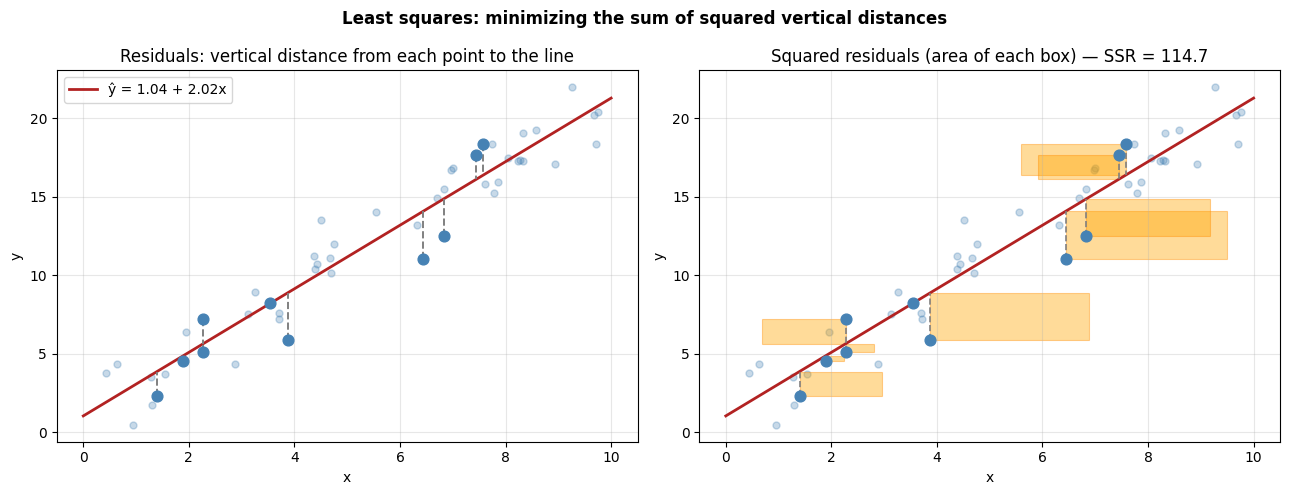

In [5]:
# illustrate least squares on a sample of points
sample_idx = rng.choice(N, size=10, replace=False)
xs, ys     = x[sample_idx], y[sample_idx]
ys_hat     = beta[0] + beta[1] * xs
es         = ys - ys_hat

x_line = np.linspace(0, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Least squares: minimizing the sum of squared vertical distances',
             fontweight='bold')

# left: residual lines
ax = axes[0]
ax.scatter(x, y, color='steelblue', alpha=0.3, s=25)
ax.scatter(xs, ys, color='steelblue', s=60, zorder=4)
ax.plot(x_line, beta[0] + beta[1] * x_line, color='firebrick', linewidth=2,
        label=f'ŷ = {beta[0]:.2f} + {beta[1]:.2f}x')
for xi, yi, yhi in zip(xs, ys, ys_hat):
    ax.plot([xi, xi], [yi, yhi], color='gray', linewidth=1.4, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Residuals: vertical distance from each point to the line')
ax.legend()
ax.grid(True, alpha=0.3)

# right: squared residuals as boxes
ax = axes[1]
ax.scatter(x, y, color='steelblue', alpha=0.3, s=25)
ax.scatter(xs, ys, color='steelblue', s=60, zorder=4)
ax.plot(x_line, beta[0] + beta[1] * x_line, color='firebrick', linewidth=2)
for xi, yi, yhi, ei in zip(xs, ys, ys_hat, es):
    side   = abs(ei)
    rect_x = xi - side if ei >= 0 else xi
    rect_y = min(yi, yhi)
    ax.add_patch(plt.Rectangle((rect_x, rect_y), side, side,
                 linewidth=0.8, edgecolor='darkorange',
                 facecolor='orange', alpha=0.4))
    ax.plot([xi, xi], [yi, yhi], color='gray', linewidth=1.2, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Squared residuals (area of each box) — SSR = {ssr:.1f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

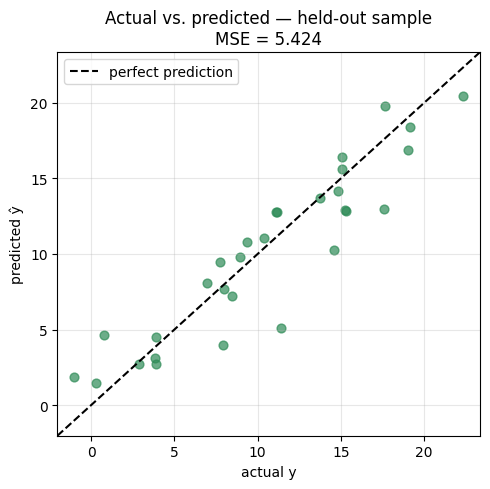

In [6]:
# actual vs. predicted on a held-out sample
x_new  = rng.uniform(0, 10, size=30)
X_new  = np.column_stack([np.ones(len(x_new)), x_new])
y_new  = TRUE_B0 + TRUE_B1 * x_new + rng.normal(0, SIGMA, size=len(x_new))
y_pred = X_new @ beta

plots.actual_vs_predicted(y_new, y_pred)

---
---

## Step 1: Multivariate Linear Regression via Least Squares

Now we generalize to $p$ predictors. The model is the same in structure — linear in the parameters, Gaussian errors — but the design matrix $\mathbf{X}$ now has $p+1$ columns (including the intercept):

$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \cdots + \beta_p x_{pi} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

In matrix notation:

$$
\mathbf{y} = \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}, \qquad
\mathbf{X} = \begin{bmatrix} 1 & x_{11} & \cdots & x_{p1} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{1n} & \cdots & x_{pn} \end{bmatrix}, \qquad
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix}
$$

The model is $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$, identical in form to the univariate case. The least squares objective is the same:

$$\text{SSR} = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

and the solution is the same normal equations:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}}$$

The formula is unchanged — only the dimensions of $\mathbf{X}$ and $\boldsymbol{\beta}$ grow. This is the power of matrix notation: the univariate case was never really special, it was always just this.

In [7]:
# generate data: 3 predictors
rng = np.random.default_rng(42)

TRUE_B = np.array([1.0, 2.0, -1.5, 0.8])   # β₀, β₁, β₂, β₃
SIGMA  = 2.0
N      = 100

X_data = rng.uniform(0, 10, size=(N, 3))
X      = np.column_stack([np.ones(N), X_data])
y      = X @ TRUE_B + rng.normal(0, SIGMA, size=N)

N_test      = 50
X_test_data = rng.uniform(0, 10, size=(N_test, 3))
X_test      = np.column_stack([np.ones(N_test), X_test_data])
y_test      = X_test @ TRUE_B + rng.normal(0, SIGMA, size=N_test)

pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'x3', 'y']).head(8).round(3)

,x1,x2,x3,y
0,7.740,4.389,8.586,16.180
1,6.974,0.942,9.756,21.133
2,7.611,7.861,1.281,4.953
3,4.504,3.708,9.268,12.165
4,6.439,8.228,4.434,8.026
5,2.272,5.546,0.638,-7.397
6,8.276,6.317,7.581,13.669
7,3.545,9.707,8.931,1.028


In [8]:
# fit via normal equations: β̂ = (X'X)⁻¹ X'y
XtX  = X.T @ X
Xty  = X.T @ y
beta = np.linalg.inv(XtX) @ Xty

print(f"{'':>4} {'estimated':>12} {'true':>10}")
print("-" * 30)
for j, (est, true) in enumerate(zip(beta, TRUE_B)):
    print(f"β{j}   {est:>12.4f} {true:>10.4f}")

        estimated       true
------------------------------
β0         1.2182     1.0000
β1         2.0274     2.0000
β2        -1.4625    -1.5000
β3         0.7253     0.8000


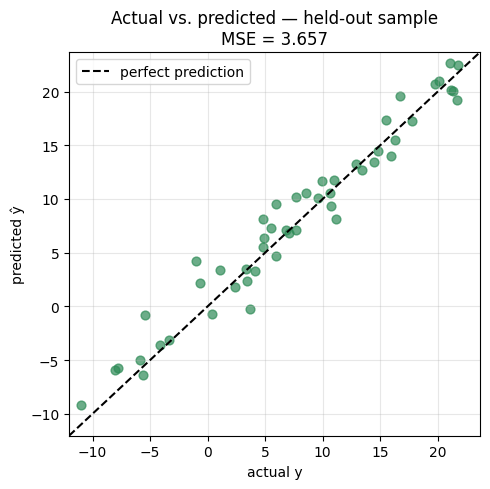

In [9]:
y_pred = X_test @ beta
plots.actual_vs_predicted(y_test, y_pred)

---
---
## Step 2: Multivariate Linear Regression via Maximum Likelihood

Steps 0 and 1 chose $\hat{\boldsymbol{\beta}}$ by minimizing a geometric criterion — the sum of squared residuals. Maximum likelihood offers a different motivation: choose the parameters that make the observed data most probable.

### The likelihood

Assuming $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ independently, each observation has the conditional density:

$$p(y_i \mid \mathbf{x}_i, \boldsymbol{\beta}, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2}{2\sigma^2}\right)$$

The likelihood over all $n$ observations is the product of these densities:

$$\mathcal{L}(\boldsymbol{\beta}, \sigma^2) = \prod_{i=1}^n p(y_i \mid \mathbf{x}_i, \boldsymbol{\beta}, \sigma^2)$$

### The log-likelihood

Products are inconvenient to optimize. Taking the log converts the product to a sum:

$$\ell(\boldsymbol{\beta}, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2$$

In matrix notation:

$$\ell(\boldsymbol{\beta}, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

### MLE equals OLS

Maximizing $\ell$ over $\boldsymbol{\beta}$ is equivalent to minimizing $(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$ — the $\sigma^2$ term is a constant with respect to $\boldsymbol{\beta}$. The MLE is therefore identical to the OLS estimator:

$$\hat{\boldsymbol{\beta}}_{\text{MLE}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y} = \hat{\boldsymbol{\beta}}_{\text{OLS}}$$

Maximizing over $\sigma^2$ separately gives:

$$\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}(\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}})^\top(\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}})$$

Note this divides by $n$ rather than $n-k$, making it slightly biased — a known and accepted property of MLE.

### Why does this matter?

The equivalence of OLS and MLE under Gaussian errors is reassuring, but MLE is the more general framework. When we change the error distribution — as we will in step 3 — least squares no longer applies, but the principle of maximizing the likelihood carries through unchanged.

In [10]:
# generate data
rng = np.random.default_rng(0)

TRUE_B = np.array([1.0, 2.0, -1.5, 0.8])
SIGMA  = 2.0
N      = 100

X_data = rng.uniform(0, 10, size=(N, 3))
X      = np.column_stack([np.ones(N), X_data])
y      = X @ TRUE_B + rng.normal(0, SIGMA, size=N)

N_test      = 50
X_test_data = rng.uniform(0, 10, size=(N_test, 3))
X_test      = np.column_stack([np.ones(N_test), X_test_data])
y_test      = X_test @ TRUE_B + rng.normal(0, SIGMA, size=N_test)

pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'x3', 'y']).head(8).round(3)

,x1,x2,x3,y
0,6.370,2.698,0.410,11.145
1,0.165,8.133,9.128,-4.150
2,6.066,7.295,5.436,7.142
3,9.351,8.159,0.027,4.964
4,8.574,0.336,7.297,25.147
5,1.757,8.632,5.415,-1.696
6,2.997,4.227,0.283,2.155
7,1.243,6.706,6.472,-0.280


In [11]:
# fit via MLE: β̂_MLE = (X'X)⁻¹ X'y
XtX  = X.T @ X
beta = np.linalg.inv(XtX) @ (X.T @ y)

resid      = y - X @ beta
sigma2_mle = (resid @ resid) / N
sigma2_ols = (resid @ resid) / (N - len(beta))

def log_likelihood(beta, sigma2, X, y):
    resid = y - X @ beta
    n = len(y)
    return -n / 2 * np.log(2 * np.pi * sigma2) - (resid @ resid) / (2 * sigma2)

ll = log_likelihood(beta, sigma2_mle, X, y)

print(f"{'':>4} {'MLE estimate':>14} {'true':>10}")
print("-" * 32)
for j, (est, true) in enumerate(zip(beta, TRUE_B)):
    print(f"β{j}   {est:>14.4f} {true:>10.4f}")
print()
print(f"σ²  MLE = {sigma2_mle:.4f}   OLS (unbiased) = {sigma2_ols:.4f}   true = {SIGMA**2:.4f}")
print(f"log-likelihood at MLE = {ll:.4f}")

# Newton's method on the Gaussian log-likelihood
# ∇ℓ = (1/σ²) X'(y - Xβ)    H = -(1/σ²) X'X  (constant — quadratic objective)
# → converges in one step from any starting point
beta_nm = np.zeros(len(beta))
ll_hist = [log_likelihood(beta_nm, sigma2_mle, X, y)]
MAX_ITER = 10
TOL      = 1e-10

for t in range(MAX_ITER):
    grad    = (1 / sigma2_mle) * (X.T @ (y - X @ beta_nm))
    H       = -(1 / sigma2_mle) * XtX
    beta_nm = beta_nm - np.linalg.solve(H, grad)
    ll_hist.append(log_likelihood(beta_nm, sigma2_mle, X, y))
    if np.linalg.norm(grad) < TOL:
        print(f'Newton converged at iteration {t+1}')
        break

       MLE estimate       true
--------------------------------
β0           1.0935     1.0000
β1           2.0290     2.0000
β2          -1.4764    -1.5000
β3           0.7052     0.8000

σ²  MLE = 3.2535   OLS (unbiased) = 3.3891   true = 4.0000
log-likelihood at MLE = -200.8811
Newton converged at iteration 2


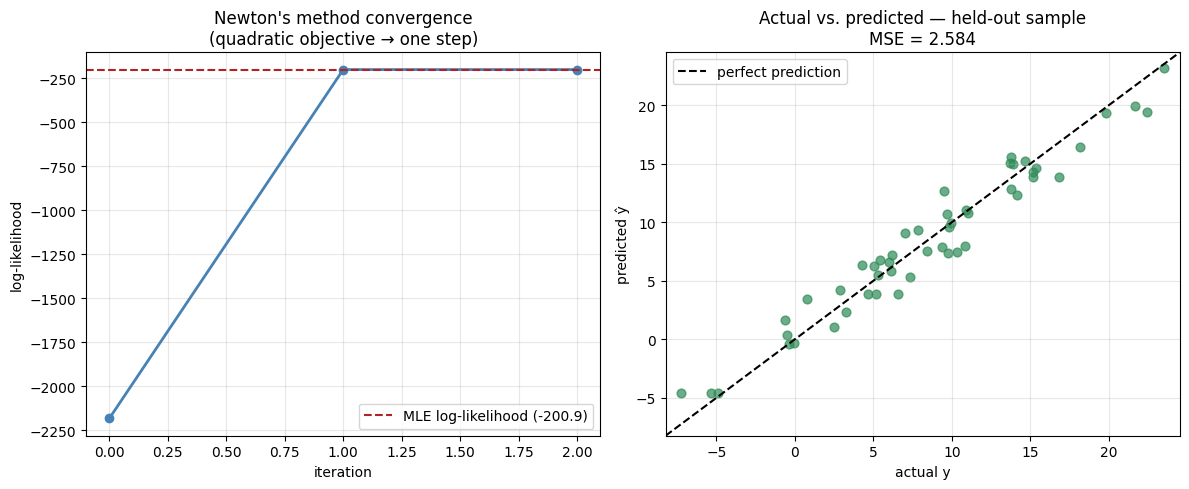

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ll_hist, color='steelblue', linewidth=2, marker='o', markersize=6)
axes[0].axhline(ll, color='firebrick', linewidth=1.5, linestyle='--',
                label=f'MLE log-likelihood ({ll:.1f})')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('log-likelihood')
axes[0].set_title("Newton's method convergence\n(quadratic objective → one step)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

y_pred = X_test @ beta
mse    = np.mean((y_test - y_pred) ** 2)
ax = axes[1]
lims = [min(y_test.min(), y_pred.min()) - 1,
        max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, color='black', linewidth=1.5, linestyle='--', label='perfect prediction')
ax.scatter(y_test, y_pred, color='seagreen', alpha=0.7, s=40)
ax.set_xlabel('actual y')
ax.set_ylabel('predicted ŷ')
ax.set_title(f'Actual vs. predicted — held-out sample\nMSE = {mse:.3f}')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
---

## Step 3: Logistic Regression via Maximum Likelihood + Newton's Method

In steps 0–2 the response $y$ was continuous. Now we switch to a binary target $y_i \in \{0, 1\}$. The Gaussian likelihood is no longer appropriate — we need a distribution over binary outcomes.

### The model

Instead of modeling $y$ directly, we model the probability that $y_i = 1$ given $\mathbf{x}_i$:

$$p_i = P(y_i = 1 \mid \mathbf{x}_i) = \sigma(\mathbf{x}_i^\top \boldsymbol{\beta})$$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the **sigmoid function**, which squashes any real value into $(0, 1)$.

### The likelihood

Each observation follows a Bernoulli distribution, so the likelihood is:

$$\mathcal{L}(\boldsymbol{\beta}) = \prod_{i=1}^n p_i^{y_i}(1 - p_i)^{1 - y_i}$$

Taking the log:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \right]$$

In matrix notation, with $\mathbf{p} = \sigma(\mathbf{X}\boldsymbol{\beta})$:

$$\ell(\boldsymbol{\beta}) = \mathbf{y}^\top \log \mathbf{p} + (\mathbf{1} - \mathbf{y})^\top \log(\mathbf{1} - \mathbf{p})$$

Unlike the Gaussian case, this has no closed-form solution — we must optimize iteratively.

### Newton's method

Newton's method uses both the gradient and the Hessian of $\ell$ to take a step directly toward the maximum:

$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \mathbf{H}^{-1}\nabla\ell(\boldsymbol{\beta}^{(t)})$$

For logistic regression the gradient and Hessian have clean forms. Let $\mathbf{W} = \text{diag}(p_i(1-p_i))$ be a diagonal matrix of per-observation weights:

$$\nabla\ell = \mathbf{X}^\top(\mathbf{y} - \mathbf{p})$$

$$\mathbf{H} = -\mathbf{X}^\top \mathbf{W} \mathbf{X}$$

The update becomes:

$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} + (\mathbf{X}^\top \mathbf{W} \mathbf{X})^{-1} \mathbf{X}^\top(\mathbf{y} - \mathbf{p})$$

This is known as **IRLS** (Iteratively Reweighted Least Squares) — at each step it solves a weighted least squares problem. Because the log-likelihood is concave, Newton's method converges to the global maximum, typically in fewer than 20 iterations.

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# generate binary classification data
rng = np.random.default_rng(42)

TRUE_B = np.array([-4.0, 0.8, 0.6])
N      = 200
N_TEST = 100

X_data = rng.uniform(0, 10, size=(N, 2))
X      = np.column_stack([np.ones(N), X_data])
y      = rng.binomial(1, sigmoid(X @ TRUE_B))

X_test_data = rng.uniform(0, 10, size=(N_TEST, 2))
X_test      = np.column_stack([np.ones(N_TEST), X_test_data])
y_test      = rng.binomial(1, sigmoid(X_test @ TRUE_B))

pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'y']).head(8).round(3)

,x1,x2,y
0,7.740,4.389,1.0
1,8.586,6.974,1.0
2,0.942,9.756,1.0
3,7.611,7.861,1.0
4,1.281,4.504,1.0
5,3.708,9.268,1.0
6,6.439,8.228,1.0
7,4.434,2.272,0.0


In [14]:
# fit via Newton's method (IRLS)
def log_likelihood_logistic(beta, X, y):
    p = sigmoid(X @ beta)
    return np.sum(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))

beta     = np.zeros(X.shape[1])
ll_hist  = []
MAX_ITER = 25
TOL      = 1e-8

for t in range(MAX_ITER):
    p    = sigmoid(X @ beta)
    ll_hist.append(log_likelihood_logistic(beta, X, y))
    grad = X.T @ (y - p)
    W    = p * (1 - p)
    H    = -(X.T * W) @ X
    step = np.linalg.solve(-H, grad)
    beta = beta + step
    if np.linalg.norm(step) < TOL:
        print(f'converged at iteration {t+1}')
        break

print(f"\n{'':>4} {'estimated':>12} {'true':>10}")
print("-" * 30)
for j, (est, true) in enumerate(zip(beta, TRUE_B)):
    print(f"β{j}   {est:>12.4f} {true:>10.4f}")

converged at iteration 8

        estimated       true
------------------------------
β0        -4.1542    -4.0000
β1         0.6994     0.8000
β2         0.7418     0.6000


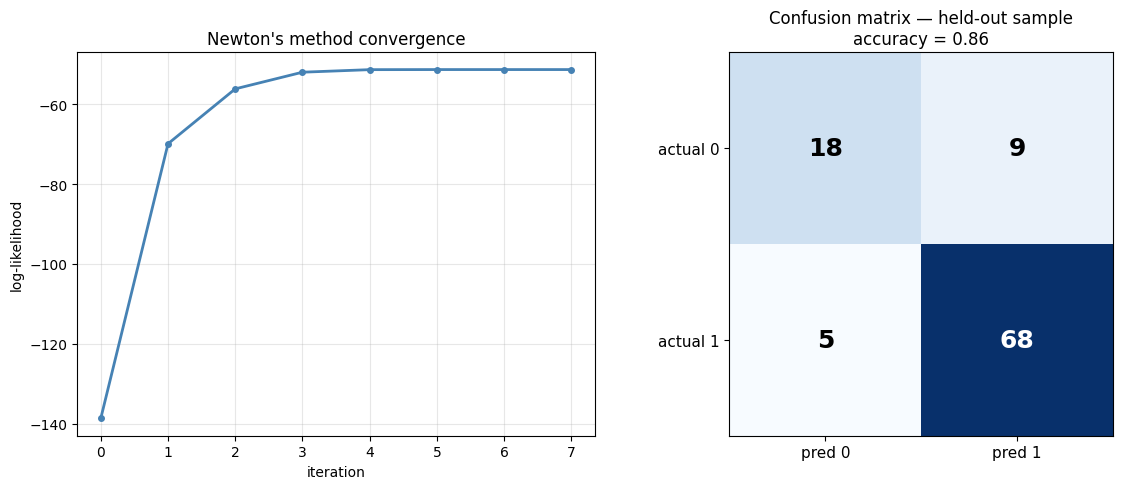

In [15]:
y_pred_prob = sigmoid(X_test @ beta)
y_pred      = (y_pred_prob >= 0.5).astype(int)
plots.convergence_and_confusion(
    ll_hist, y_test, y_pred,
    class_labels=['0', '1'],
    ylabel='log-likelihood',
    conv_title="Newton's method convergence",
)

---
---

## Step 4: Logistic Regression via Gradient Descent

Step 3 used Newton's method, which converges in very few iterations by using curvature information (the Hessian). The cost is computing and inverting an $p \times p$ matrix at every step — $O(p^3)$ work that becomes infeasible when $p$ is large.

**Gradient descent** trades curvature for scalability. It ignores the Hessian entirely and takes small steps in the direction of the gradient:

$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} + \eta \nabla\ell(\boldsymbol{\beta}^{(t)})$$

where $\eta > 0$ is the **learning rate**. For logistic regression the gradient is the same as before:

$$\nabla\ell = \mathbf{X}^\top(\mathbf{y} - \mathbf{p}), \qquad \mathbf{p} = \sigma(\mathbf{X}\boldsymbol{\beta})$$

Each step costs only $O(np)$ — a matrix-vector product — with no matrix inversion. Convergence is slower than Newton (linear rather than quadratic), but the per-step cost is dramatically lower, and crucially, the approach generalises to any differentiable loss function regardless of whether a Hessian is tractable. This is why gradient descent — not Newton's method — is the engine behind every modern neural network.

In [16]:
# reusing X, y, X_test, y_test from step 0 — same data, different optimizer
pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'y']).head(8).round(3)

,x1,x2,y
0,7.740,4.389,1.0
1,8.586,6.974,1.0
2,0.942,9.756,1.0
3,7.611,7.861,1.0
4,1.281,4.504,1.0
5,3.708,9.268,1.0
6,6.439,8.228,1.0
7,4.434,2.272,0.0


In [17]:
# fit via gradient descent
LR       = 0.001
MAX_ITER = 2_000
TOL      = 1e-6

beta    = np.zeros(X.shape[1])
ll_hist = []

for t in range(MAX_ITER):
    p    = sigmoid(X @ beta)
    ll   = log_likelihood_logistic(beta, X, y)
    ll_hist.append(ll)
    grad = X.T @ (y - p)
    beta = beta + LR * grad
    if np.linalg.norm(grad) < TOL:
        print(f'converged at iteration {t+1}')
        break

# newton's method log-likelihood for comparison (recomputed from step 0 beta)
beta_newton = np.zeros(X.shape[1])
for _ in range(25):
    p_n    = sigmoid(X @ beta_newton)
    grad_n = X.T @ (y - p_n)
    H_n    = -(X.T * (p_n * (1 - p_n))) @ X
    step   = np.linalg.solve(-H_n, grad_n)
    beta_newton += step
    if np.linalg.norm(step) < 1e-8:
        break
ll_newton = log_likelihood_logistic(beta_newton, X, y)

print(f"\n{'':>4} {'GD estimate':>14} {'Newton estimate':>17} {'true':>10}")
print("-" * 48)
for j, (gd, nw, true) in enumerate(zip(beta, beta_newton, TRUE_B)):
    print(f"β{j}   {gd:>14.4f} {nw:>17.4f} {true:>10.4f}")
print(f"\nlog-likelihood  GD = {ll_hist[-1]:.4f}   Newton = {ll_newton:.4f}")


        GD estimate   Newton estimate       true
------------------------------------------------
β0          -4.0225           -4.1542    -4.0000
β1           0.6820            0.6994     0.8000
β2           0.7235            0.7418     0.6000

log-likelihood  GD = -51.3691   Newton = -51.3562


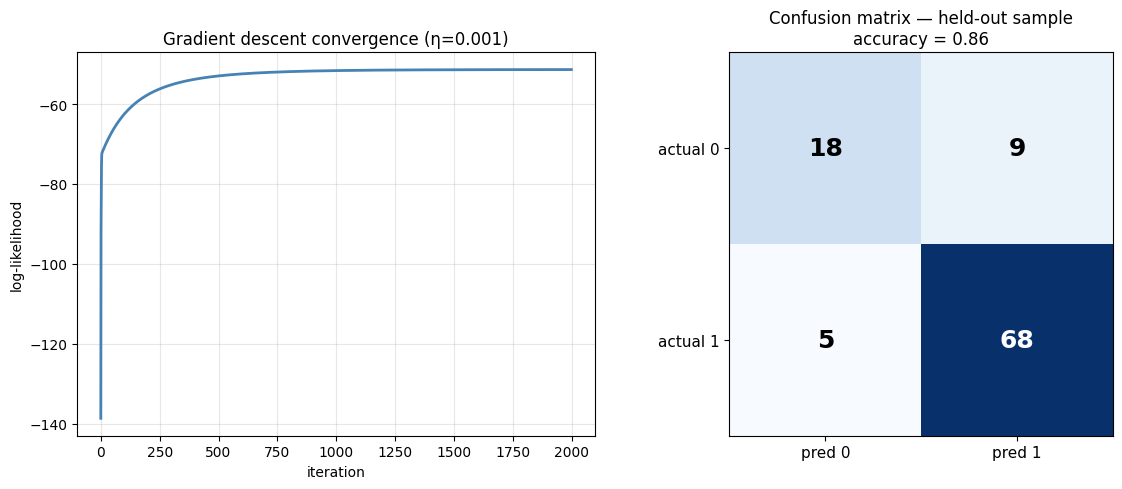

In [18]:
y_pred_prob = sigmoid(X_test @ beta)
y_pred      = (y_pred_prob >= 0.5).astype(int)
plots.convergence_and_confusion(
    ll_hist, y_test, y_pred,
    class_labels=['0', '1'],
    ylabel='log-likelihood',
    conv_title=f'Gradient descent convergence (η={LR})',
)

---
---

## Step 5: Logistic Regression via Gradient Descent (PyTorch)

The model and the optimizer are identical to step 4 — same gradient descent update, same data. The only change is the framework: we switch from NumPy to **PyTorch**.

### The loss function is the negative log-likelihood

In step 4 we *maximised* the Bernoulli log-likelihood:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]$$

PyTorch *minimises* a loss, so we flip the sign and divide by $n$:

$$\mathcal{L}(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^n \left[ y_i \log p_i + (1-y_i)\log(1-p_i) \right]$$

This is exactly `nn.BCELoss(reduction='mean')` — **binary cross-entropy**. The name comes from information theory but the formula is identical to the negative log-likelihood of the Bernoulli distribution. Maximising the likelihood and minimising the binary cross-entropy loss are the same optimisation problem.

We use `reduction='sum'` rather than `'mean'` so that the gradient scale matches our NumPy implementation, allowing a direct comparison of results.

### What PyTorch adds

- **Parameters** are `torch.Tensor` objects with `requires_grad=True` so PyTorch tracks gradients automatically via a computation graph
- **`loss.backward()`** traverses the graph and computes $\partial \mathcal{L} / \partial \boldsymbol{\beta}$ — no hand-coded gradient
- **The optimizer** (`torch.optim.SGD`) applies the update rule

In [19]:
# reusing X, y, X_test, y_test from step 0/5 — same data throughout
# convert to torch tensors (drop the intercept column — nn.Linear adds its own bias)
X_t      = torch.tensor(X_data,      dtype=torch.float32)
y_t      = torch.tensor(y,           dtype=torch.float32)
X_test_t = torch.tensor(X_test_data, dtype=torch.float32)
y_test_t = torch.tensor(y_test,      dtype=torch.float32)

pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'y']).head(8).round(3)

,x1,x2,y
0,7.740,4.389,1.0
1,8.586,6.974,1.0
2,0.942,9.756,1.0
3,7.611,7.861,1.0
4,1.281,4.504,1.0
5,3.708,9.268,1.0
6,6.439,8.228,1.0
7,4.434,2.272,0.0


In [20]:
# logistic regression as a single linear layer + sigmoid
model     = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
criterion = nn.BCELoss(reduction='sum')   # sum matches the numpy log-likelihood gradient
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

MAX_ITER  = 2_000
loss_hist = []

for t in range(MAX_ITER):
    y_pred = model(X_t).squeeze()
    loss   = criterion(y_pred, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

w = model[0].weight.data.numpy().flatten()
b = model[0].bias.data.numpy().flatten()
print(f"Learned β: intercept={b[0]:.4f}  w1={w[0]:.4f}  w2={w[1]:.4f}")
print(f"True β:    intercept={TRUE_B[0]:.4f}  w1={TRUE_B[1]:.4f}  w2={TRUE_B[2]:.4f}")

Learned β: intercept=-4.0130  w1=0.6808  w2=0.7222
True β:    intercept=-4.0000  w1=0.8000  w2=0.6000


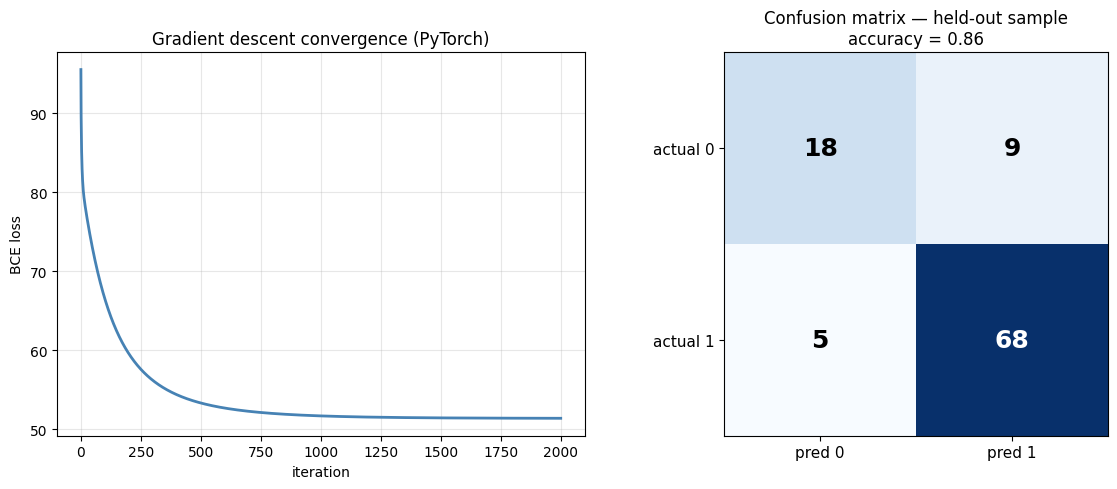

In [21]:
with torch.no_grad():
    y_pred_prob = model(X_test_t).squeeze().numpy()
y_pred = (y_pred_prob >= 0.5).astype(int)
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=['0', '1'],
    ylabel='BCE loss',
    conv_title='Gradient descent convergence (PyTorch)',
)

---
---

## Step 6: Neural Network with a Hidden Layer (PyTorch)

In step 5 the model was a single linear transformation followed by a sigmoid:

$$\hat{y} = \sigma(\mathbf{x}^\top \boldsymbol{\beta})$$

The decision boundary this produces is always a straight line — no matter how many gradient steps we take, a linear model can only separate classes that are linearly separable.

Adding a **hidden layer** breaks this limitation. We insert a layer of intermediate units between the input and the output, each computing a linear combination of the inputs followed by a nonlinear activation function:

$$\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)$$
$$\hat{y} = \sigma(\mathbf{w}_2^\top \mathbf{h} + b_2)$$

We use sigmoid activations throughout for now — the same function we already know — so the only new idea is the hidden layer itself. Without a nonlinear activation between the two linear layers they would collapse back into a single linear transformation, so the $\sigma$ in the hidden layer is essential.

In PyTorch this is just one extra `nn.Linear` + `nn.Sigmoid` in the `nn.Sequential` stack. The training loop is completely unchanged. The diagram below shows what changes.

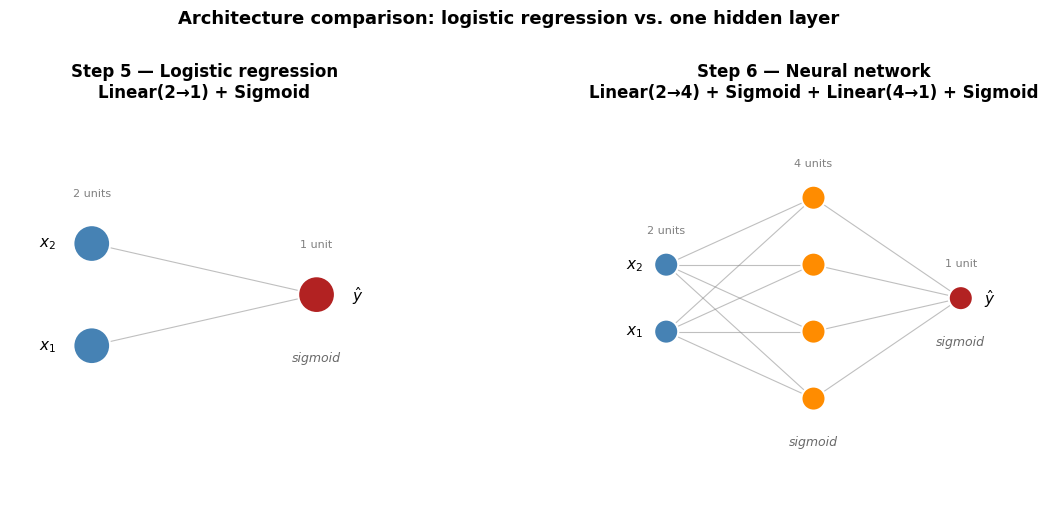

In [22]:
diagrams.step6()

In [23]:
# reusing X, y, X_test, y_test from steps 4/5/6 — same data throughout
pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'y']).head(8).round(3)

,x1,x2,y
0,7.740,4.389,1.0
1,8.586,6.974,1.0
2,0.942,9.756,1.0
3,7.611,7.861,1.0
4,1.281,4.504,1.0
5,3.708,9.268,1.0
6,6.439,8.228,1.0
7,4.434,2.272,0.0


In [24]:
# neural network: Linear(2→4) + Sigmoid + Linear(4→1) + Sigmoid
model     = nn.Sequential(
                nn.Linear(2, 4),
                nn.Sigmoid(),
                nn.Linear(4, 1),
                nn.Sigmoid(),
            )
criterion = nn.BCELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

MAX_ITER  = 2_000
loss_hist = []

for t in range(MAX_ITER):
    y_pred = model(X_t).squeeze()
    loss   = criterion(y_pred, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

total parameters: 17
final loss: 49.4166


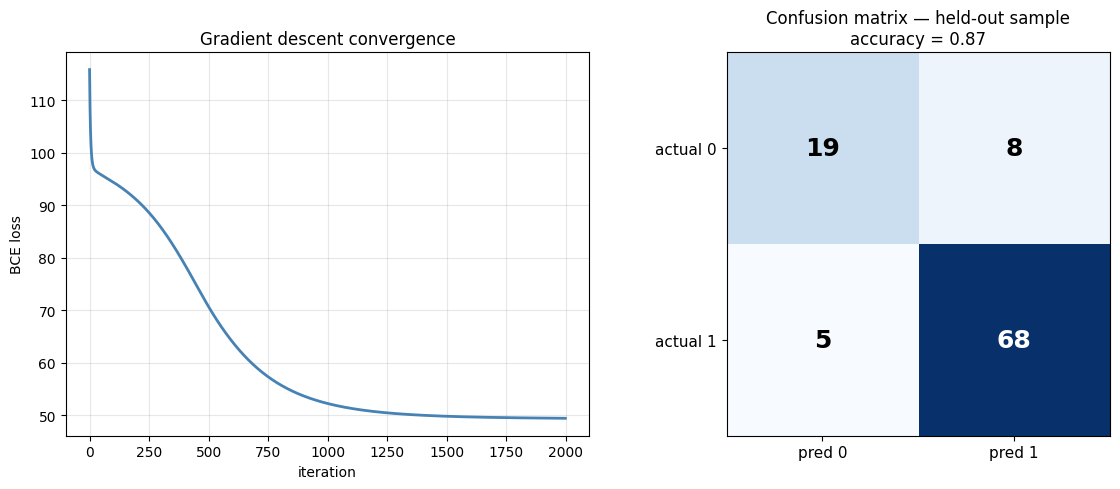

In [25]:
with torch.no_grad():
    y_pred_prob = model(X_test_t).squeeze().numpy()
y_pred = (y_pred_prob >= 0.5).astype(int)
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=['0', '1'],
    ylabel='BCE loss',
    conv_title='Gradient descent convergence',
)

---
---

## Step 7: Neural Network with ReLU Hidden Layer (PyTorch)

Step 6 used sigmoid activations in the hidden layer. While sigmoid works, it has a well-known problem: **vanishing gradients**. The sigmoid function saturates — for large positive or negative inputs, its output is nearly flat and its derivative approaches zero:

$$\sigma'(z) = \sigma(z)(1 - \sigma(z)) \quad \xrightarrow{|z| \to \infty} \quad 0$$

When gradients are propagated back through many saturated sigmoid units, they shrink toward zero and the early layers learn very slowly. This is the main reason deep networks with sigmoid activations are difficult to train.

**ReLU** (Rectified Linear Unit) largely solves this:

$$\text{ReLU}(z) = \max(0, z)$$

For any positive input the gradient is exactly 1 — it neither explodes nor vanishes. For negative inputs the unit is simply off (zero output). This asymmetry makes ReLU networks faster to train and less prone to saturation, which is why it became the default activation in modern deep learning.

The plot below shows the key difference:

- **Sigmoid**: smooth, bounded in $(0,1)$, saturates at both ends
- **ReLU**: linear for positive inputs, zero for negative, never saturates on the positive side

Everything else in step 7 is identical to step 6 — same data, same architecture shape, same training loop. Only the hidden activation changes.

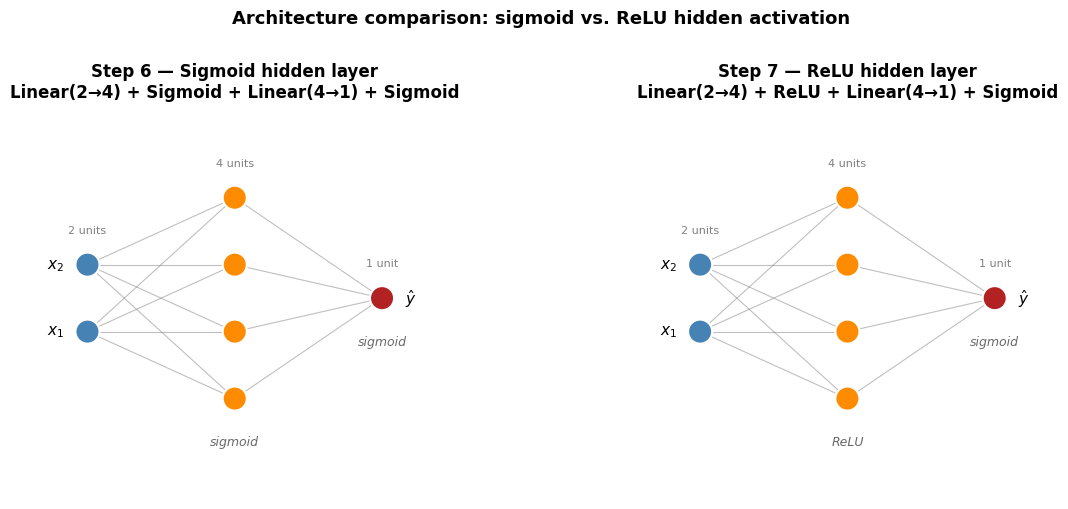

In [26]:
diagrams.step7()

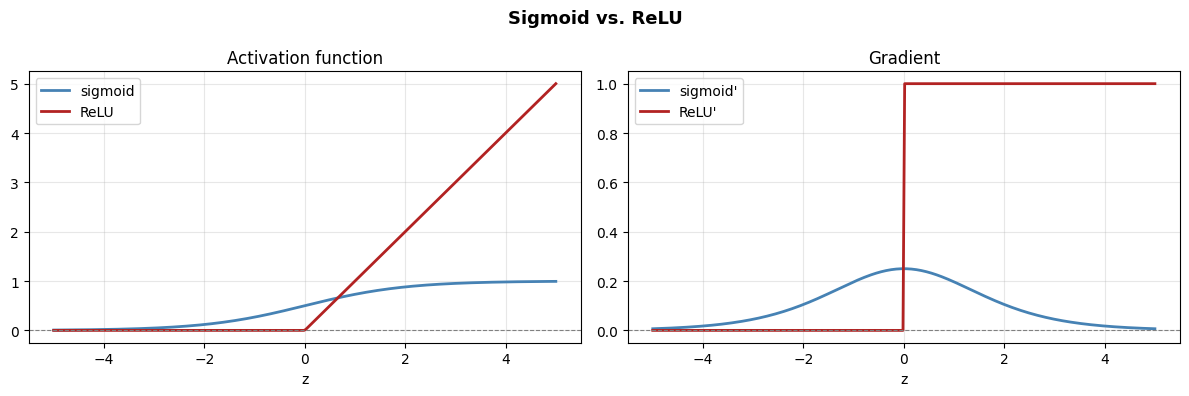

In [27]:
diagrams.step7_activations()

In [28]:
# reusing X, y, X_test, y_test from steps 4–7 — same data throughout
pd.DataFrame(np.column_stack([X_data, y]), columns=['x1', 'x2', 'y']).head(8).round(3)

,x1,x2,y
0,7.740,4.389,1.0
1,8.586,6.974,1.0
2,0.942,9.756,1.0
3,7.611,7.861,1.0
4,1.281,4.504,1.0
5,3.708,9.268,1.0
6,6.439,8.228,1.0
7,4.434,2.272,0.0


In [29]:
# neural network: Linear(2→4) + ReLU + Linear(4→1) + Sigmoid
model     = nn.Sequential(
                nn.Linear(2, 4),
                nn.ReLU(),
                nn.Linear(4, 1),
                nn.Sigmoid(),
            )
criterion = nn.BCELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

MAX_ITER  = 2_000
loss_hist = []

for t in range(MAX_ITER):
    y_pred = model(X_t).squeeze()
    loss   = criterion(y_pred, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

total parameters: 17
final loss: 50.5568


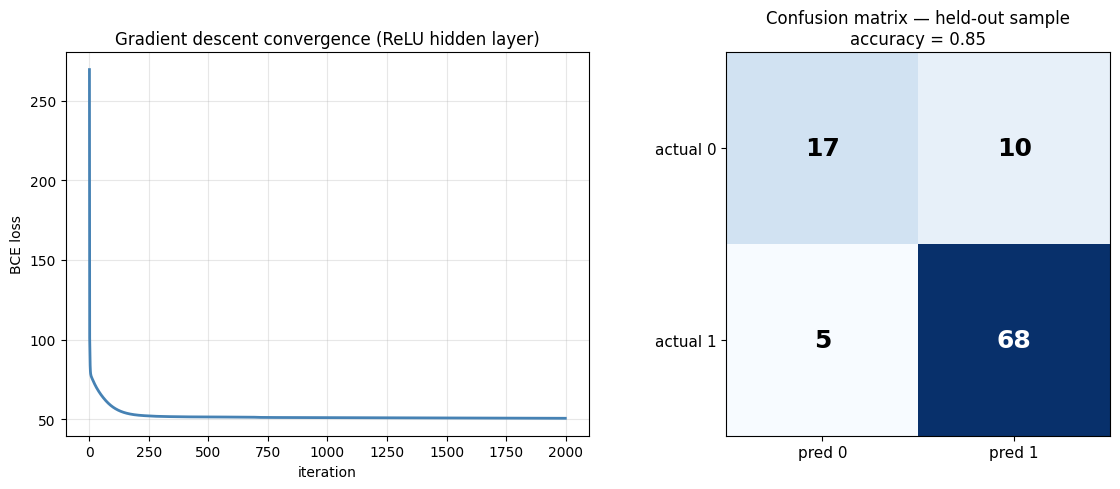

In [30]:
with torch.no_grad():
    y_pred_prob = model(X_test_t).squeeze().numpy()
y_pred = (y_pred_prob >= 0.5).astype(int)
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=['0', '1'],
    ylabel='BCE loss',
    conv_title='Gradient descent convergence (ReLU hidden layer)',
)

---
---
## Step 8: Multi-class Classification with Softmax (PyTorch)

Steps 3–7 had a binary target — the output was a single probability $\hat{p} = P(y=1 \mid \mathbf{x})$. Now we generalise to $K$ classes. Instead of one output unit we have $K$, and instead of a sigmoid we apply a **softmax** to turn the raw outputs into a probability distribution over classes:

$$\hat{p}_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}, \qquad \mathbf{z} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$$

The softmax guarantees $\hat{p}_k > 0$ and $\sum_k \hat{p}_k = 1$. Note that sigmoid is a special case of softmax for $K=2$.

### The loss

The natural loss is the **categorical cross-entropy** — the negative log-likelihood of the categorical distribution:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^n \log \hat{p}_{y_i}$$

where $\hat{p}_{y_i}$ is the predicted probability assigned to the true class of observation $i$. This is exactly `nn.CrossEntropyLoss` in PyTorch, which combines a log-softmax and a negative log-likelihood in a single numerically stable operation.

### Architecture change

The only change from step 7 is the output layer: `nn.Linear(4, 1)` + `nn.Sigmoid()` becomes `nn.Linear(4, 5)` (softmax is handled internally by the loss). The hidden layer is unchanged.

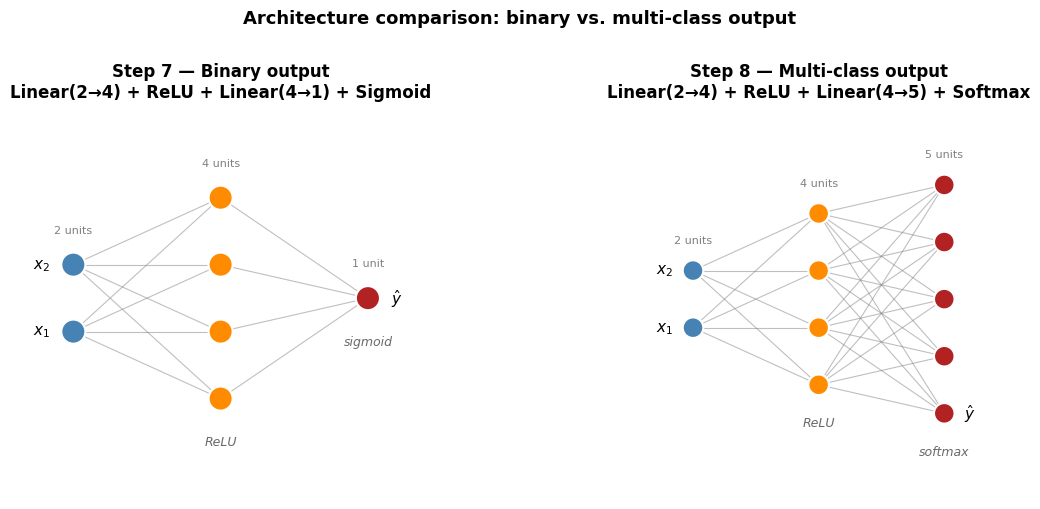

In [31]:
diagrams.step8()

In [32]:
# generate 5-class Gaussian blob data
rng = np.random.default_rng(42)

CLASSES   = ['a', 'b', 'c', 'd', 'e']
K         = len(CLASSES)
N_PER     = 100
N         = N_PER * K
N_TEST    = 50 * K

# class centres spread around a circle so no two are adjacent
centres = np.array([
    [ 0.0,  3.0],
    [ 3.0,  0.0],
    [ 0.0, -3.0],
    [-3.0,  0.0],
    [ 0.0,  0.0],   # centre class is harder to separate
])

X_data = np.vstack([
    rng.normal(loc=centres[k], scale=0.9, size=(N_PER, 2)) for k in range(K)
])
y      = np.repeat(np.arange(K), N_PER)

X_test_data = np.vstack([
    rng.normal(loc=centres[k], scale=0.9, size=(50, 2)) for k in range(K)
])
y_test = np.repeat(np.arange(K), 50)

# shuffle training set
idx    = rng.permutation(N)
X_data, y = X_data[idx], y[idx]

df = pd.DataFrame(X_data, columns=['x1', 'x2'])
df['y'] = [CLASSES[i] for i in y]
df.head(8).round(3)

,x1,x2,y
0,-0.565,0.280,e
1,0.599,2.911,a
2,1.293,0.476,e
3,0.995,-3.866,c
4,1.263,-3.398,c
5,-0.996,2.195,a
6,-4.026,-1.008,d
7,3.081,0.205,b


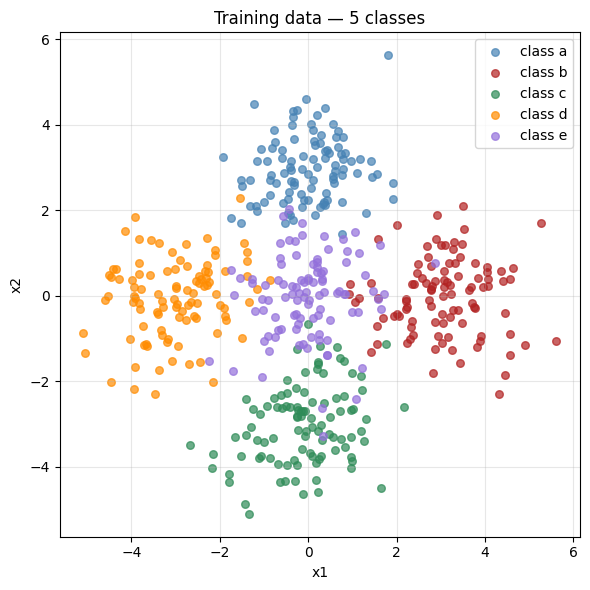

In [33]:
# scatter plot of training data
colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(6, 6))
for k, (cls, color) in enumerate(zip(CLASSES, colors)):
    mask = y == k
    ax.scatter(X_data[mask, 0], X_data[mask, 1], color=color,
               alpha=0.7, s=30, label=f'class {cls}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Training data — 5 classes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# convert to tensors
X_t      = torch.tensor(X_data,      dtype=torch.float32)
y_t      = torch.tensor(y,           dtype=torch.long)
X_test_t = torch.tensor(X_test_data, dtype=torch.float32)
y_test_t = torch.tensor(y_test,      dtype=torch.long)

# model: Linear(2→4) + ReLU + Linear(4→5)
# CrossEntropyLoss applies log-softmax internally so no softmax in the model
model     = nn.Sequential(
                nn.Linear(2, 4),
                nn.ReLU(),
                nn.Linear(4, K),
            )
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

MAX_ITER  = 10_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

total parameters: 37
final loss: 0.1993


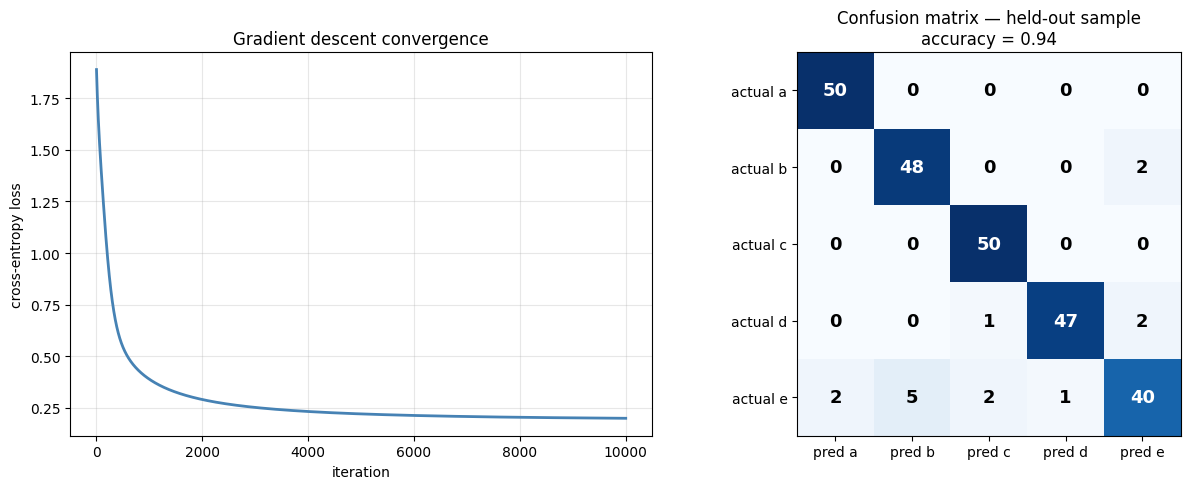

In [35]:
with torch.no_grad():
    y_pred = model(X_test_t).argmax(dim=1).numpy()
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=CLASSES,
    ylabel='cross-entropy loss',
    conv_title='Gradient descent convergence',
)

---
---

## Step 9: Multi-class Classification with Discrete Inputs via One-Hot Encoding (PyTorch)

In steps 0–8 the inputs were continuous numbers. Now the inputs are **discrete symbols** — each observation is a pair of characters drawn from the vocabulary $\{v, w, x, y, z\}$, and the target is one of $\{a, b, c, d, e\}$.

A neural network expects real-valued vectors, not symbols. The simplest way to represent a discrete symbol is **one-hot encoding**: map each symbol to a binary vector of length $|V|$ with a single 1 in the position corresponding to that symbol:

$$v \to [1,0,0,0,0], \quad w \to [0,1,0,0,0], \quad \ldots \quad z \to [0,0,0,0,1]$$

Two input symbols concatenated give a vector of length $2 \times 5 = 10$, which we feed into the same network as before. Everything downstream — the hidden layer, ReLU, softmax output, cross-entropy loss, gradient descent — is unchanged.

This is the key point: **the model doesn't know or care that its inputs came from symbols**. One-hot encoding is just a convention for turning a categorical variable into something a linear layer can multiply. In step 10 we will replace this fixed encoding with a learned one — the embedding layer — but the network structure stays the same.

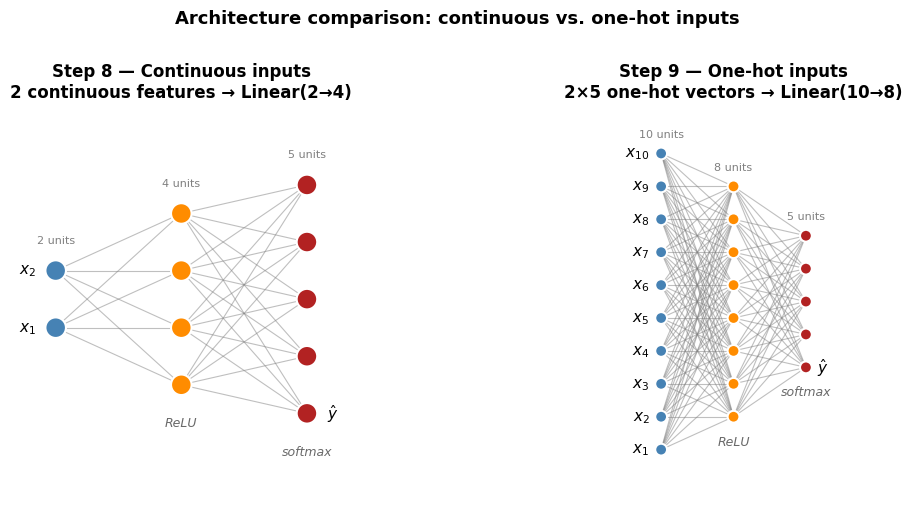

In [36]:
diagrams.step9()

In [37]:
# generate discrete input data
rng = np.random.default_rng(42)

IN_VOCAB  = list('vwxyz')   # input symbols
OUT_VOCAB = list('abcde')   # target classes
V         = len(IN_VOCAB)
K         = len(OUT_VOCAB)
N         = 1_000
N_TEST    = 200

# mapping: class is determined by (i1 + i2) mod 5, with 15% label noise
def make_dataset(n, rng):
    i1   = rng.integers(0, V, size=n)
    i2   = rng.integers(0, V, size=n)
    y    = (i1 + i2) % K
    flip = rng.random(n) < 0.15
    y[flip] = rng.integers(0, K, size=flip.sum())
    return i1, i2, y

i1_train, i2_train, y_train = make_dataset(N,      rng)
i1_test,  i2_test,  y_test  = make_dataset(N_TEST, rng)

# one-hot encode and concatenate both inputs → length-10 vector
def one_hot_pair(i1, i2, V):
    n  = len(i1)
    oh = np.zeros((n, 2 * V), dtype=np.float32)
    oh[np.arange(n), i1]     = 1.0
    oh[np.arange(n), i2 + V] = 1.0
    return oh

X_train = one_hot_pair(i1_train, i2_train, V)
X_test  = one_hot_pair(i1_test,  i2_test,  V)

# raw symbols
df_raw = pd.DataFrame({
    'input 1': [IN_VOCAB[i] for i in i1_train],
    'input 2': [IN_VOCAB[i] for i in i2_train],
    'target':  [OUT_VOCAB[c] for c in y_train],
})

# one-hot encoded
oh_cols = [f'i1={c}' for c in IN_VOCAB] + [f'i2={c}' for c in IN_VOCAB]
df_oh   = pd.DataFrame(X_train[:8].astype(int), columns=oh_cols)
df_oh['target'] = [OUT_VOCAB[c] for c in y_train[:8]]

print('Raw symbols:')
display(df_raw.head(8))
print('\nAfter one-hot encoding:')
display(df_oh)

Raw symbols:


,input 1,input 2,target
0,v,z,b
1,y,y,b
2,y,x,e
3,x,z,b
4,x,v,c
5,z,z,d
6,v,z,e
7,y,x,a



After one-hot encoding:


,i1=v,i1=w,i1=x,i1=y,i1=z,i2=v,i2=w,i2=x,i2=y,i2=z,target
0,1,0,0,0,0,0,0,0,0,1,b
1,0,0,0,1,0,0,0,0,1,0,b
2,0,0,0,1,0,0,0,1,0,0,e
3,0,0,1,0,0,0,0,0,0,1,b
4,0,0,1,0,0,1,0,0,0,0,c
5,0,0,0,0,1,0,0,0,0,1,d
6,1,0,0,0,0,0,0,0,0,1,e
7,0,0,0,1,0,0,0,1,0,0,a


In [38]:
# convert to tensors
X_t      = torch.tensor(X_train, dtype=torch.float32)
y_t      = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test,  dtype=torch.float32)
y_test_t = torch.tensor(y_test,  dtype=torch.long)

# model: Linear(10→8) + ReLU + Linear(8→5)
model     = nn.Sequential(
                nn.Linear(2 * V, 8),
                nn.ReLU(),
                nn.Linear(8, K),
            )
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

MAX_ITER  = 10_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

total parameters: 133
final loss: 0.4774


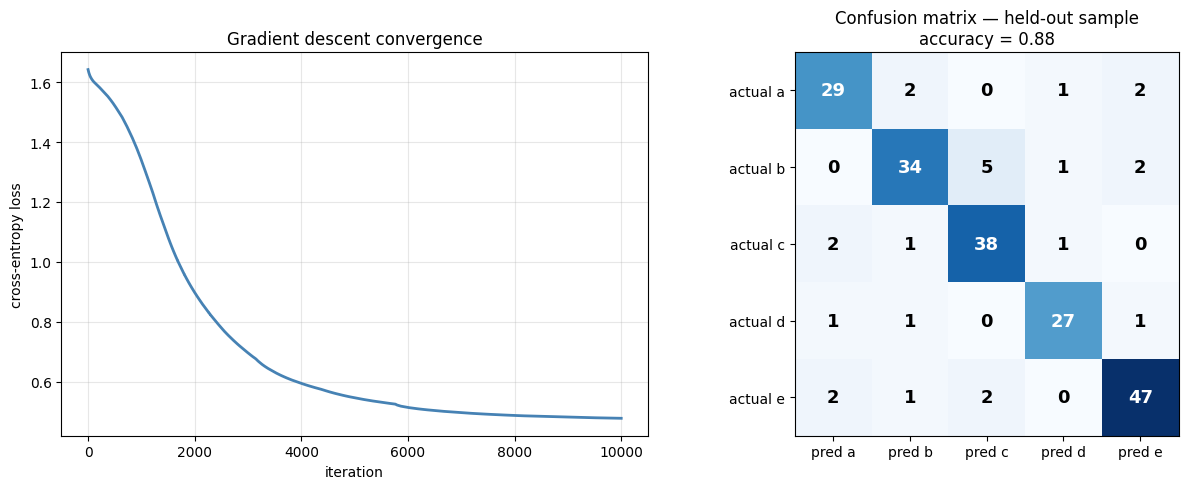

In [39]:
with torch.no_grad():
    y_pred = model(X_test_t).argmax(dim=1).numpy()
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=OUT_VOCAB,
    ylabel='cross-entropy loss',
    conv_title='Gradient descent convergence',
)

---
---

## Step 10: Discrete Inputs via Learned Embeddings (PyTorch)

In step 9 we represented each input symbol as a one-hot vector — a fixed, hand-crafted encoding that treats all symbols as equally dissimilar. The network then had to learn any useful structure about the symbols from scratch through its weight matrices.

**Learned embeddings** do this more directly. Instead of a fixed one-hot vector, each symbol gets a dense vector of length $d$ that is learned end-to-end alongside the rest of the network:

$$\mathbf{e}_k = \mathbf{E}[k, :] \qquad \mathbf{E} \in \mathbb{R}^{V \times d}$$

where $\mathbf{E}$ is the **embedding matrix** and $k$ is the integer index of the symbol. This is implemented in PyTorch as `nn.Embedding(V, d)` — a simple lookup table. Here we use $d = 4$, so each symbol maps to a 4-dimensional vector and the concatenated input has the same dimension (8) as the one-hot input in step 9 — making the two architectures directly comparable.

### The connection to one-hot encoding

An embedding lookup is mathematically identical to multiplying a one-hot vector by a weight matrix:

$$\mathbf{E}[k, :] = \mathbf{e}_k^\top \mathbf{E} \quad \text{where } \mathbf{e}_k = [0, \ldots, 1, \ldots, 0]$$

The difference is efficiency and expressiveness — instead of storing and multiplying sparse $V$-dimensional vectors, we store a dense $d$-dimensional vector directly. When $d \ll V$ this is a significant compression, and the geometry of the learned embedding space can capture meaningful relationships between symbols.

Everything else — hidden layer, ReLU, softmax output, cross-entropy loss — is unchanged. The same data and task as step 9.

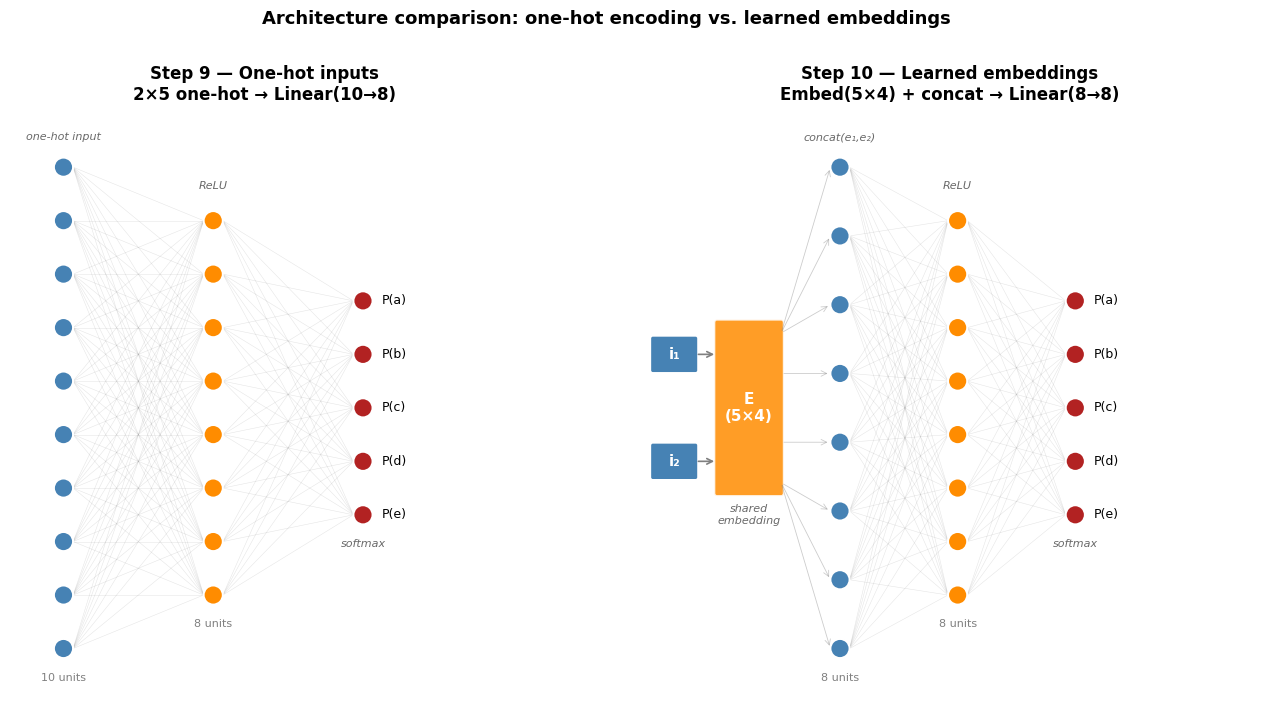

In [40]:
diagrams.step10(out_vocab=OUT_VOCAB)

### The lookup in detail

The embedding matrix $\mathbf{E}$ has shape $(V \times d)$ — one row per vocabulary symbol. Here $V=5$ (symbols v–z) and $d=4$, so $\mathbf{E} \in \mathbb{R}^{5 \times 4}$.

For a single observation with input symbols $i_1$ and $i_2$:

$$\mathbf{e}_1 = \mathbf{E}[i_1, :] \in \mathbb{R}^4 \qquad \mathbf{e}_2 = \mathbf{E}[i_2, :] \in \mathbb{R}^4$$

The two vectors are concatenated to form the input to the hidden layer:

$$\mathbf{x} = [\mathbf{e}_1 \,\|\, \mathbf{e}_2] \in \mathbb{R}^{8}$$

This flows into `Linear(8→8)` + ReLU + `Linear(8→5)`. **Both inputs share the same $\mathbf{E}$** — there is only one set of $5 \times 4 = 20$ embedding parameters, not two separate tables.

In [41]:
# reusing i1_train, i2_train, y_train, i1_test, i2_test, y_test from step 0
i1_t      = torch.tensor(i1_train, dtype=torch.long)
i2_t      = torch.tensor(i2_train, dtype=torch.long)
y_t       = torch.tensor(y_train,  dtype=torch.long)
i1_test_t = torch.tensor(i1_test,  dtype=torch.long)
i2_test_t = torch.tensor(i2_test,  dtype=torch.long)
y_test_t  = torch.tensor(y_test,   dtype=torch.long)

pd.DataFrame({
    'input 1': [IN_VOCAB[i] for i in i1_train],
    'input 2': [IN_VOCAB[i] for i in i2_train],
    'target':  [OUT_VOCAB[c] for c in y_train],
}).head(8)

,input 1,input 2,target
0,v,z,b
1,y,y,b
2,y,x,e
3,x,z,b
4,x,v,c
5,z,z,d
6,v,z,e
7,y,x,a


In [42]:
EMBED_DIM = 4   # each symbol → 4-dimensional vector

class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes):
        super().__init__()
        self.emb     = nn.Embedding(vocab_size, embed_dim)
        self.network = nn.Sequential(
                           nn.Linear(2 * embed_dim, hidden_dim),
                           nn.ReLU(),
                           nn.Linear(hidden_dim, n_classes),
                       )

    def forward(self, i1, i2):
        # look up embeddings, concatenate, pass through network
        x = torch.cat([self.emb(i1), self.emb(i2)], dim=1)
        return self.network(x)

model     = EmbeddingClassifier(V, EMBED_DIM, hidden_dim=8, n_classes=K)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

MAX_ITER  = 5_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(i1_t, i2_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

# show the learned embedding vectors
emb_weights = model.emb.weight.detach().numpy()
df_emb = pd.DataFrame(emb_weights.round(3),
                       index=list(IN_VOCAB),
                       columns=[f'dim {i}' for i in range(EMBED_DIM)])
df_emb.index.name = 'symbol'
print('\nLearned embedding vectors:')
display(df_emb)

total parameters: 137
final loss: 0.4851

Learned embedding vectors:


,dim 0,dim 1,dim 2,dim 3
symbol,,,,
v,0.150,-1.528,-1.705,2.206
w,1.811,-0.633,-2.442,-1.295
x,2.352,0.582,1.373,-1.060
y,-3.119,0.416,1.176,-2.566
z,-2.049,-1.975,-0.249,-0.003


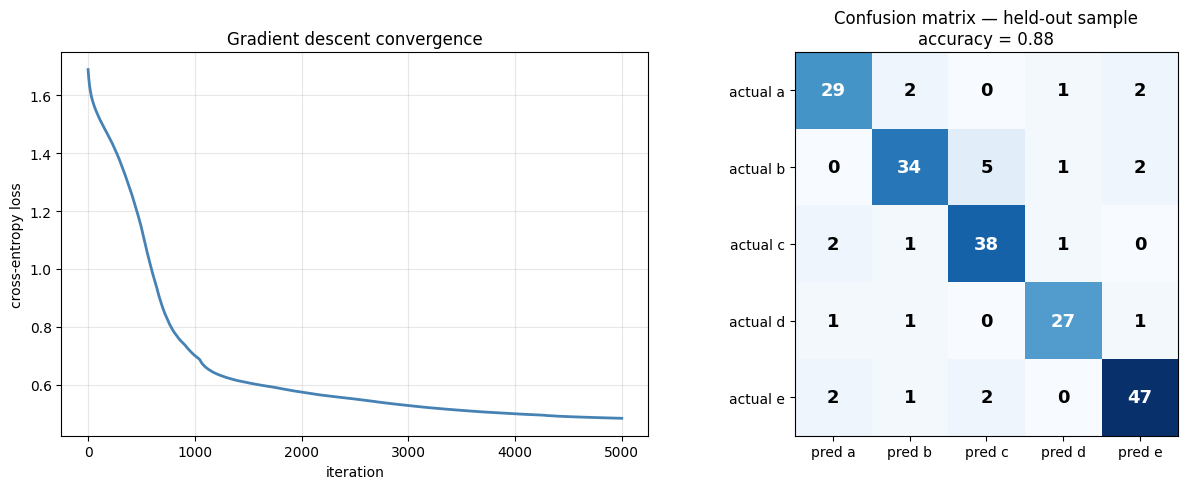

In [43]:
with torch.no_grad():
    y_pred = model(i1_test_t, i2_test_t).argmax(dim=1).numpy()
plots.convergence_and_confusion(
    loss_hist, y_test, y_pred,
    class_labels=OUT_VOCAB,
    ylabel='cross-entropy loss',
    conv_title='Gradient descent convergence',
)

---
---

## Step 11: Character-level Language Model — 2-character Context (PyTorch)

Steps 9 and 10 used simulated data with a fixed classification target. Now we switch to a real task: **character-level language modeling**. Given the two most recent characters in a sequence, predict the next one.

This is the same architecture as step 10 — EMBED_DIM=4, hidden=8 — two symbol inputs, each looked up in a shared embedding, concatenated, passed through a hidden layer, softmax output. The only things that change are:

- **Task**: predict the next character instead of a fixed class
- **Data**: real text instead of simulated pairs
- **Vocabulary**: all unique characters in the text (~30–40 symbols) instead of just {v–z}

The loss is still categorical cross-entropy — we're still doing multi-class classification, just with characters as both inputs and targets. This is exactly what a language model does: at every position, assign a probability distribution over the vocabulary for the next token.

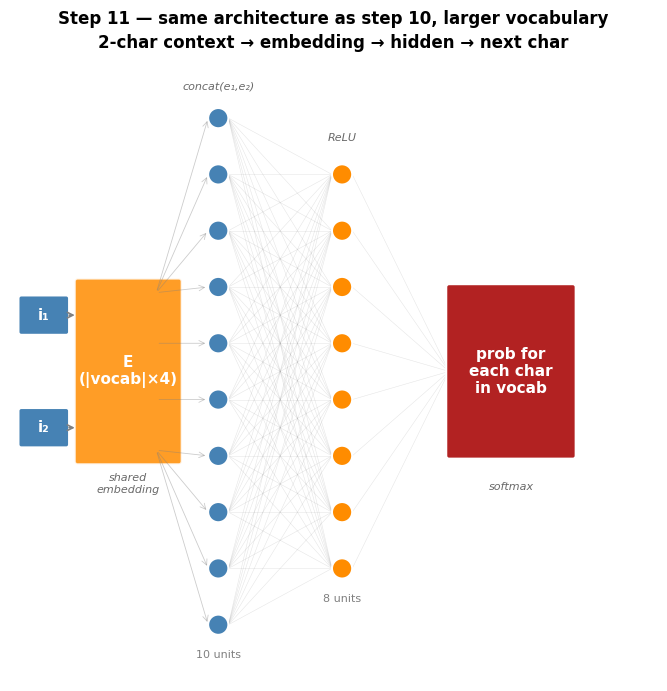

In [44]:
diagrams.step11()


### The data
We slide a window of width 3 across the text. Each window $(c_t, c_{t+1}, c_{t+2})$ produces one training example: inputs $(c_t, c_{t+1})$, target $c_{t+2}$. With enough text this yields thousands of overlapping examples from a single passage.

In [45]:
# build character-level dataset from a short passage
text = (
    "it was the best of times it was the worst of times "
    "it was the age of wisdom it was the age of foolishness "
    "it was the epoch of belief it was the epoch of incredulity "
    "it was the season of light it was the season of darkness "
    "it was the spring of hope it was the winter of despair "
    "we had everything before us we had nothing before us "
    "we were all going direct to heaven we were all going direct the other way"
).lower()

# vocabulary: all unique characters, sorted
vocab     = sorted(set(text))
V_CHAR    = len(vocab)
ch2idx    = {c: i for i, c in enumerate(vocab)}
idx2ch    = {i: c for c, i in ch2idx.items()}

# sliding window of width 3 → (c_t, c_{t+1}) → c_{t+2}
i1 = [ch2idx[text[i]]   for i in range(len(text) - 2)]
i2 = [ch2idx[text[i+1]] for i in range(len(text) - 2)]
tg = [ch2idx[text[i+2]] for i in range(len(text) - 2)]

i1 = np.array(i1); i2 = np.array(i2); tg = np.array(tg)

# train / test split (last 20% held out)
split     = int(0.8 * len(i1))
i1_train, i1_test = i1[:split], i1[split:]
i2_train, i2_test = i2[:split], i2[split:]
tg_train, tg_test = tg[:split], tg[split:]

print(f'vocabulary size: {V_CHAR}  ({repr("".join(vocab))})')
print(f'train examples: {len(i1_train)}   test examples: {len(i1_test)}')

# show how the text is chopped into input/target triples
print("How the text is segmented into training examples:\n")
for i in range(12):
    c1 = repr(idx2ch[i1_train[i]])
    c2 = repr(idx2ch[i2_train[i]])
    ct = repr(idx2ch[tg_train[i]])
    print(f"  input 1 = {c1:4s}  input 2 = {c2:4s}  →  target = {ct}")

# show a few examples
df_ex = pd.DataFrame({
    'c_t':   [idx2ch[i] for i in i1_train[:8]],
    'c_t+1': [idx2ch[i] for i in i2_train[:8]],
    'c_t+2 (target)': [idx2ch[i] for i in tg_train[:8]],
})
display(df_ex)

vocabulary size: 23  (' abcdefghiklmnoprstuvwy')
train examples: 320   test examples: 81
How the text is segmented into training examples:

  input 1 = 'i'   input 2 = 't'   →  target = ' '
  input 1 = 't'   input 2 = ' '   →  target = 'w'
  input 1 = ' '   input 2 = 'w'   →  target = 'a'
  input 1 = 'w'   input 2 = 'a'   →  target = 's'
  input 1 = 'a'   input 2 = 's'   →  target = ' '
  input 1 = 's'   input 2 = ' '   →  target = 't'
  input 1 = ' '   input 2 = 't'   →  target = 'h'
  input 1 = 't'   input 2 = 'h'   →  target = 'e'
  input 1 = 'h'   input 2 = 'e'   →  target = ' '
  input 1 = 'e'   input 2 = ' '   →  target = 'b'
  input 1 = ' '   input 2 = 'b'   →  target = 'e'
  input 1 = 'b'   input 2 = 'e'   →  target = 's'


,c_t,c_t+1,c_t+2 (target)
0,i,t,
1,t,,w
2,,w,a
3,w,a,s
4,a,s,
5,s,,t
6,,t,h
7,t,h,e


In [46]:
EMBED_DIM = 4   # each character → 4-dimensional vector

i1_t = torch.tensor(i1_train, dtype=torch.long)
i2_t = torch.tensor(i2_train, dtype=torch.long)
tg_t = torch.tensor(tg_train, dtype=torch.long)
i1_test_t = torch.tensor(i1_test, dtype=torch.long)
i2_test_t = torch.tensor(i2_test, dtype=torch.long)
tg_test_t = torch.tensor(tg_test, dtype=torch.long)

model     = EmbeddingClassifier(V_CHAR, EMBED_DIM, hidden_dim=8, n_classes=V_CHAR)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

MAX_ITER  = 3_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(i1_t, i2_t)
    loss   = criterion(logits, tg_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

n_params = sum(p.numel() for p in model.parameters())
print(f'vocabulary size: {V_CHAR}   total parameters: {n_params}')
print(f'final loss: {loss_hist[-1]:.4f}')

vocabulary size: 23   total parameters: 371
final loss: 0.5051


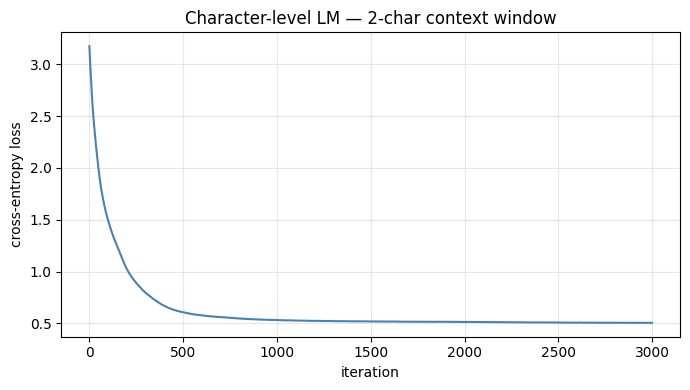

test accuracy: 0.210   (random baseline: 0.043)


In [47]:
with torch.no_grad():
    y_pred = model(i1_test_t, i2_test_t).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — 2-char context window',
                  vocab_size=V_CHAR, y_test=tg_test, y_pred=y_pred)

### Generating text

Once the model is trained we can use it autoregressively to generate new text. Starting from a 2-character seed, we:

1. Feed the last two characters into the model to get a probability distribution over the vocabulary
2. Sample the next character from that distribution
3. Append it to the sequence and repeat

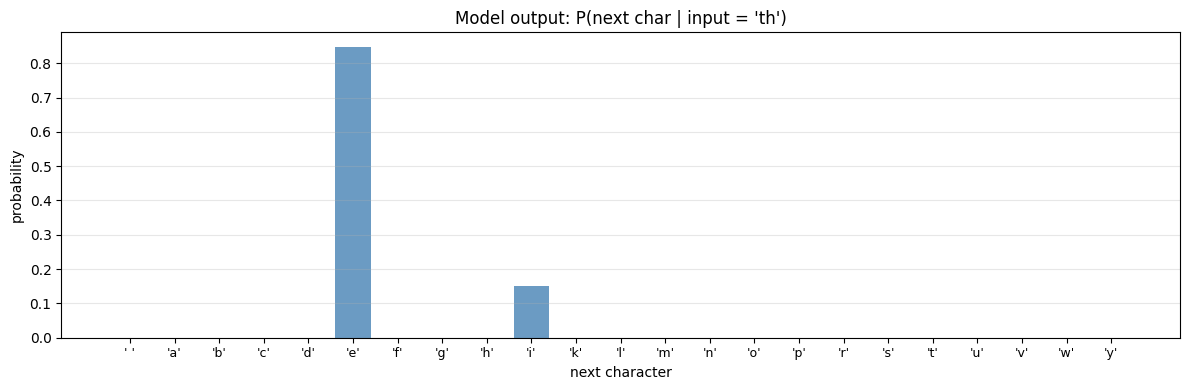

Top 5 predicted next characters:
  'e'   0.848
  'i'   0.152
  'a'   0.000
  ' '   0.000
  'm'   0.000


In [48]:
seed = 'th'
c1 = torch.tensor([ch2idx[seed[0]]], dtype=torch.long)
c2 = torch.tensor([ch2idx[seed[1]]], dtype=torch.long)

model.eval()
with torch.no_grad():
    probs = torch.softmax(model(c1, c2).squeeze(), dim=0).numpy()

plots.probability_distribution(probs, vocab=vocab, seed=seed)

In [49]:
# generate text by sampling from the model
def generate(seed, n_chars=200):
    """autoregressively sample characters given a 2-char seed."""
    assert len(seed) >= 2, 'seed must be at least 2 characters'
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            i1_in = torch.tensor([ch2idx[result[-2]]], dtype=torch.long)
            i2_in = torch.tensor([ch2idx[result[-1]]], dtype=torch.long)
            probs  = torch.softmax(model(i1_in, i2_in).squeeze(), dim=0).numpy()
            next_c = idx2ch[np.random.choice(V_CHAR, p=probs)]
            result.append(next_c)
    return ''.join(result)

print(generate('it', n_chars=300))

it we of the seas thinterythe wason of thing bess it of it wing of hope had nothe hope had ever wing bef ing beliefoolishnespnifooliefoolishnest wishness timess the age wason of it winter it of the spair of incre hope we age of was it was thing belieforst winterythe was the wisdom ing of it was it we 


---
---

## Step 12: Single-Head Self-Attention (PyTorch)

In step 11 the two embeddings are concatenated and fed into a linear layer with fixed weights. The network learns one set of weights for position 1 and another for position 2 — there is no mechanism for the embeddings to influence each other.

**Self-attention** fixes this. It is a mechanism that allows each embedding vector to absorb information from every other embedding vector in the context — including itself. The amount absorbed from each position is determined dynamically by the content of the tokens, not by fixed positional weights.

The output has the same shape as the input: one updated vector per position. Each output vector is a context-aware version of the original embedding, enriched by information from the surrounding positions.

Here is how it works, step by step.

### Step 12.1: look up embeddings

For a context of $T = 2$ tokens, look up both rows of **E** and stack them:

$$\mathbf{E}_{1:T} = \begin{bmatrix} \mathbf{e}_1 \\ \mathbf{e}_2 \end{bmatrix} \qquad (2 \times 4)$$

### Step 12.2: project into Q, K, V

Each embedding is projected into three vectors via learned weight matrices. The **query** asks what to look for, the **key** advertises what is available, and the **value** is the actual information to be absorbed. With $d_k = d_v = 4$:

$$\mathbf{Q} = \mathbf{E}_{1:T}\,\mathbf{W}_Q \qquad (2 \times 4) \cdot (4 \times 4) = (2 \times 4)$$

$$\mathbf{K} = \mathbf{E}_{1:T}\,\mathbf{W}_K \qquad (2 \times 4) \cdot (4 \times 4) = (2 \times 4)$$

$$\mathbf{V} = \mathbf{E}_{1:T}\,\mathbf{W}_V \qquad (2 \times 4) \cdot (4 \times 4) = (2 \times 4)$$

### Step 12.3: compute attention scores

Dot each query against every key to get a $(T \times T)$ matrix of raw scores, then scale by $\sqrt{d_k}$:

$$\mathbf{A} = \frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}} \qquad (2 \times 4) \cdot (4 \times 2) = (2 \times 2)$$

Entry $(i, j)$ is the raw score for how much position $i$ should attend to position $j$.

### Step 12.4: softmax over scores

Apply softmax row-wise so each row sums to 1 — a probability distribution over positions:

$$\boldsymbol{\alpha} = \mathrm{softmax}(\mathbf{A}) \qquad (2 \times 2)$$

### Step 12.5: weighted sum of values

Multiply the attention weights by $\mathbf{V}$. Each output row is a weighted blend of all value vectors — this is the information absorption:

$$\mathbf{O} = \boldsymbol{\alpha}\,\mathbf{V} \qquad (2 \times 2) \cdot (2 \times 4) = (2 \times 4)$$

$\mathbf{O}$ has the same shape as the input embeddings $(2 \times 4)$. Each row $\mathbf{o}_i$ is an updated embedding for position $i$, now enriched by information from all other positions. This replaces the concatenation from step 11.

### Connecting attention to the rest of the network

We now have two updated embedding vectors $\mathbf{o}_1$ and $\mathbf{o}_2$, each of shape $(1 \times 4)$. To keep the rest of the network identical to step 11, we simply concatenate them:

$$[\mathbf{o}_1 \,\|\, \mathbf{o}_2] \qquad (1 \times 8)$$

This feeds into `Linear(8→8) + ReLU + Linear(8→|V|)` — exactly the same as before. The only change from step 11 is that instead of concatenating the raw embeddings, we concatenate the attention outputs. The downstream network, loss, and training loop are unchanged.

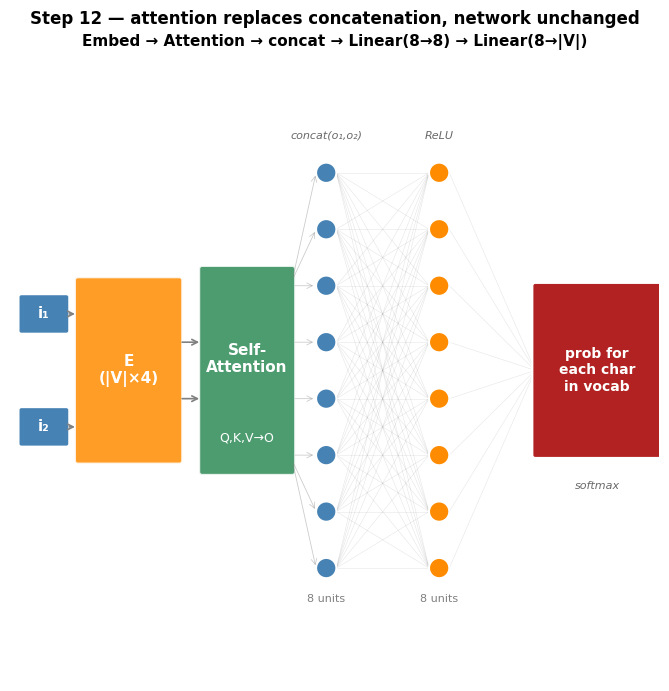

In [50]:
diagrams.step12(out_vocab=OUT_VOCAB)

In [51]:
# reusing text, vocab, ch2idx, idx2ch, and train/test splits from step 0
print(f'vocabulary size: {V_CHAR}  context: 2 chars  embed dim: 4')

df_ex = pd.DataFrame({
    'c_t':            [idx2ch[i] for i in i1_train[:8]],
    'c_t+1':          [idx2ch[i] for i in i2_train[:8]],
    'c_t+2 (target)': [idx2ch[i] for i in tg_train[:8]],
})
display(df_ex)

vocabulary size: 23  context: 2 chars  embed dim: 4


,c_t,c_t+1,c_t+2 (target)
0,i,t,
1,t,,w
2,,w,a
3,w,a,s
4,a,s,
5,s,,t
6,,t,h
7,t,h,e


In [52]:
class SelfAttentionLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_classes):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim)
        self.W_Q  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.fc1  = nn.Linear(embed_dim * 2, embed_dim * 2)   # concat(o1,o2) → 8
        self.fc2  = nn.Linear(embed_dim * 2, n_classes)

    def forward(self, i1, i2):
        # step 0: embeddings  →  (batch, 2, embed_dim)
        e = torch.stack([self.emb(i1), self.emb(i2)], dim=1)

        # step 0: project into Q, K, V  →  each (batch, 2, embed_dim)
        Q = self.W_Q(e)
        K = self.W_K(e)
        V = self.W_V(e)

        # step 0: scaled dot-product attention scores  →  (batch, 2, 2)
        d_k = Q.shape[-1]
        A   = (Q @ K.transpose(-2, -1)) / d_k ** 0.5

        # step 0: softmax over scores  →  (batch, 2, 2)
        alpha = torch.softmax(A, dim=-1)

        # step 0: weighted sum of values  →  (batch, 2, embed_dim)
        O = alpha @ V

        # concat both output vectors and pass through the same network as step 0
        x = O.flatten(start_dim=1)          # (batch, 2 * embed_dim)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


EMBED_DIM = 4
model     = SelfAttentionLM(V_CHAR, EMBED_DIM, n_classes=V_CHAR)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')

total parameters: 419


In [53]:
MAX_ITER  = 8_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(i1_t, i2_t)
    loss   = criterion(logits, tg_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.5769


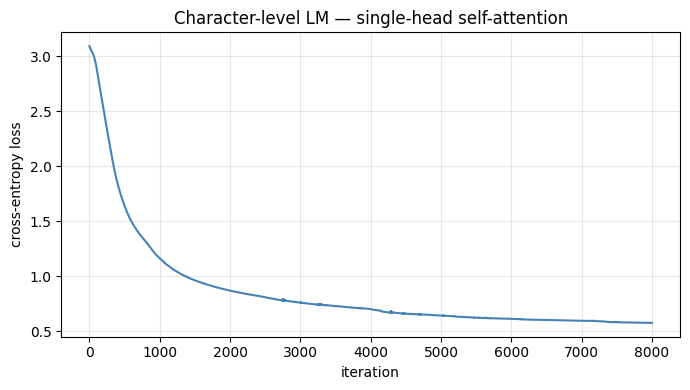

test accuracy: 0.235   (random baseline: 0.043)


In [54]:
with torch.no_grad():
    y_pred = model(i1_test_t, i2_test_t).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — single-head self-attention',
                  vocab_size=V_CHAR, y_test=tg_test, y_pred=y_pred)

In [55]:
def generate_attn(seed, n_chars=300):
    """autoregressively sample using the attention model."""
    assert len(seed) >= 2
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            i1_in = torch.tensor([ch2idx[result[-2]]], dtype=torch.long)
            i2_in = torch.tensor([ch2idx[result[-1]]], dtype=torch.long)
            probs  = torch.softmax(model(i1_in, i2_in).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_attn('it', n_chars=300))

it was tir wasoolismespring of despainmimesto of timest was it of darknespair of das it we had epoch of beforathing of was it wasnothe age age it was the of foolight was the seas thad nothe of wasooliefrlrgo of wason of bess the seas the seas ity it we everythe it was was it we seas tight was it was t


---
---

## Step 13: Causal Masking

In step 12 the attention mechanism allows every position to attend to every other position — including positions that come *after* it. For a language model this is a problem: when predicting the character at position $t$, the model should not be able to see characters at positions $t+1, t+2, \ldots$ — those are in the future.

**Causal masking** enforces this by zeroing out future attention weights before the softmax. We add $-\infty$ to the upper triangle of the attention score matrix $\mathbf{A}$ before applying softmax:

$$\mathbf{A}_{\text{masked}} = \mathbf{A} + \mathbf{M}, \qquad M_{ij} = \begin{cases} 0 & i \geq j \\ -\infty & i < j \end{cases}$$

For our 2-token context this gives:

$$\mathbf{A}_{\text{masked}} = \begin{bmatrix} a_{11} & -\infty \\ a_{21} & a_{22} \end{bmatrix}$$

After softmax, $-\infty$ becomes 0, so position 1 attends only to itself, and position 2 attends to both positions. The mask is fixed — it does not depend on the input — so it can be precomputed once and reused every forward pass.

This is the single change that makes the model properly autoregressive. Everything else — embeddings, Q/K/V projections, concatenation, downstream network — is unchanged.

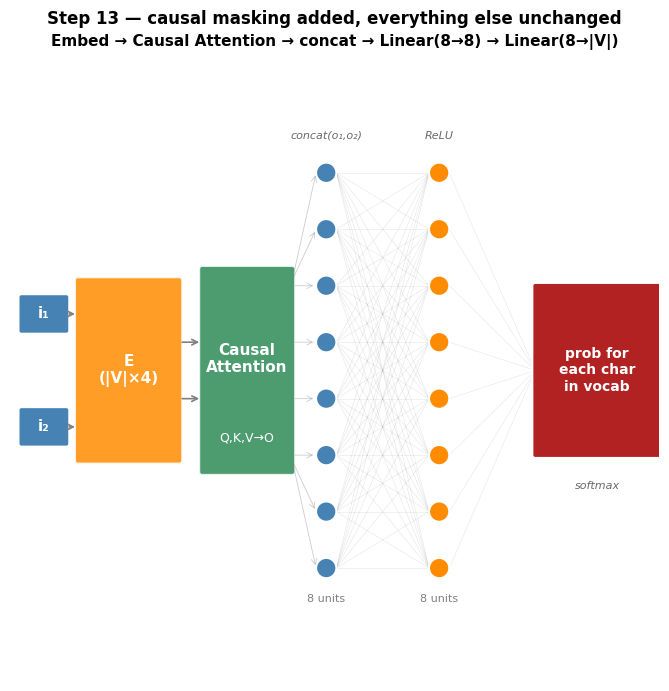

In [56]:
diagrams.step13()

In [57]:
class CausalSelfAttentionLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_classes):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim)
        self.W_Q  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.fc1  = nn.Linear(embed_dim * context_len, embed_dim * context_len)
        self.fc2  = nn.Linear(embed_dim * context_len, n_classes)

        # causal mask: upper triangle = -inf, lower triangle + diagonal = 0
        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask', mask)   # saved with model, not a parameter

    def forward(self, i1, i2):
        e = torch.stack([self.emb(i1), self.emb(i2)], dim=1)  # (batch, 2, embed_dim)

        Q = self.W_Q(e)
        K = self.W_K(e)
        V = self.W_V(e)

        d_k   = Q.shape[-1]
        A     = (Q @ K.transpose(-2, -1)) / d_k ** 0.5   # (batch, 2, 2)
        A     = A + self.mask                              # apply causal mask
        alpha = torch.softmax(A, dim=-1)

        O = alpha @ V                                      # (batch, 2, embed_dim)
        x = O.flatten(start_dim=1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


EMBED_DIM   = 4
CONTEXT_LEN = 2
model       = CausalSelfAttentionLM(V_CHAR, EMBED_DIM, CONTEXT_LEN, n_classes=V_CHAR)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')

# show the causal mask
print(f'\ncausal mask (2×2):')
print(model.mask)

total parameters: 419

causal mask (2×2):
tensor([[0., -inf],
        [0., 0.]])


In [58]:
MAX_ITER  = 8_000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(i1_t, i2_t)
    loss   = criterion(logits, tg_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.5473


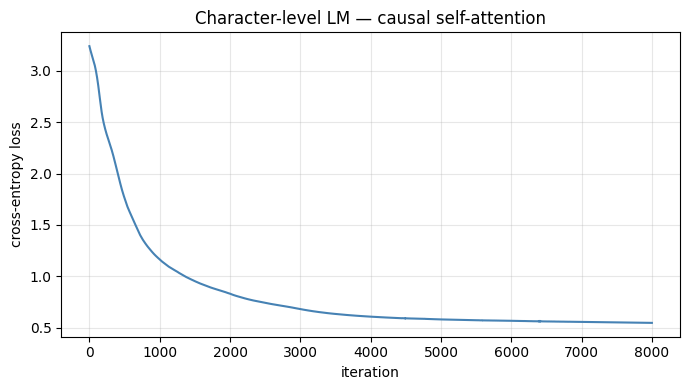

test accuracy: 0.284   (random baseline: 0.043)


In [59]:
with torch.no_grad():
    y_pred = model(i1_test_t, i2_test_t).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — causal self-attention',
                  vocab_size=V_CHAR, y_test=tg_test, y_pred=y_pred)

In [60]:
def generate_causal(seed, n_chars=300):
    assert len(seed) >= 2
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            i1_in = torch.tensor([ch2idx[result[-2]]], dtype=torch.long)
            i2_in = torch.tensor([ch2idx[result[-1]]], dtype=torch.long)
            probs  = torch.softmax(model(i1_in, i2_in).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_causal('it', n_chars=300))

ity ing of beliefoat wason of the epoch of lit wishne seas timess int was the seas the epoch of it woreduligh of the it we it wason of hope had ns thing befororst was was was the thinterything belit was things it was the was it we it was it was the age hope was it was the of des the epoch of was the o


---
---

## Step 14: Use Last Output Only — Expand to 5-character Context

In steps 12 and 13 we concatenated both attention output vectors before the linear layer. This works but it doesn't scale — with a context of length $T$, the input to the linear layer grows as $T \times d_e$, requiring a different-sized network for every context length.

With causal masking in place, we can do better. The last output vector $\mathbf{o}_T$ has already attended to all previous positions — it is the only one we need:

$$\mathbf{o}_T \in \mathbb{R}^{d_e} \quad \rightarrow \quad \text{Linear}(d_e \rightarrow |V|)$$

The linear layer input is now always $d_e = 4$ regardless of context length. This is exactly how GPT works — process the full context through attention, then read off only the last position's output to make the prediction.

We also expand the context window from 2 to 5 characters. The architecture handles this without any structural change — only the causal mask and the input tensor grow to $(5 \times 5)$ and $(\text{batch} \times 5)$ respectively. We also switch to a single input tensor of shape $(\text{batch} \times T)$ rather than separate per-position arguments, which is the natural format for variable-length contexts.

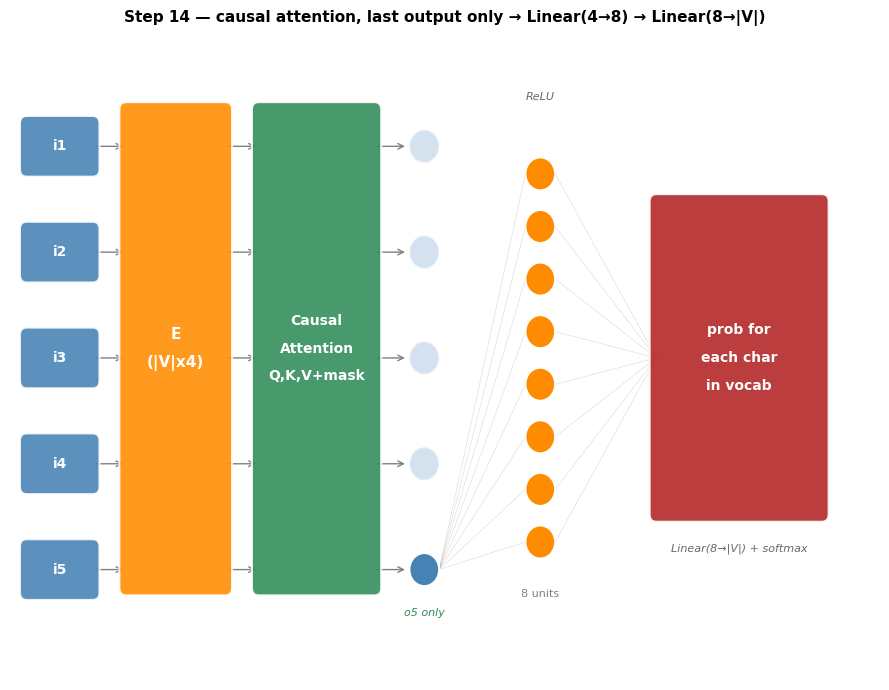

In [61]:
diagrams.step14()

In [62]:
CONTEXT_LEN = 5

# rebuild dataset with 5-char context windows: (c_t … c_{t+4}) → c_{t+5}
def make_lm_dataset(text, context_len, ch2idx):
    X = np.array([[ch2idx[text[i+j]] for j in range(context_len)]
                  for i in range(len(text) - context_len)])
    y = np.array([ch2idx[text[i + context_len]]
                  for i in range(len(text) - context_len)])
    return X, y

X_lm, y_lm = make_lm_dataset(text, CONTEXT_LEN, ch2idx)
split       = int(0.8 * len(X_lm))
X_train_lm, X_test_lm = X_lm[:split], X_lm[split:]
y_train_lm, y_test_lm = y_lm[:split], y_lm[split:]

X_t  = torch.tensor(X_train_lm, dtype=torch.long)
y_t  = torch.tensor(y_train_lm, dtype=torch.long)
X_tt = torch.tensor(X_test_lm,  dtype=torch.long)
y_tt = torch.tensor(y_test_lm,  dtype=torch.long)

print(f'context length: {CONTEXT_LEN}  train: {len(X_train_lm)}  test: {len(X_test_lm)}')

df_ex = pd.DataFrame(
    [[text[i+j] for j in range(CONTEXT_LEN)] + [text[i+CONTEXT_LEN]]
     for i in range(8)],
    columns=[f'c_t+{j}' for j in range(CONTEXT_LEN)] + ['target']
)
display(df_ex)

context length: 5  train: 318  test: 80


,c_t+0,c_t+1,c_t+2,c_t+3,c_t+4,target
0,i,t,,w,a,s
1,t,,w,a,s,
2,,w,a,s,,t
3,w,a,s,,t,h
4,a,s,,t,h,e
5,s,,t,h,e,
6,,t,h,e,,b
7,t,h,e,,b,e


In [63]:
class LastOutputLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_classes):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, embed_dim, bias=False)
        self.fc1 = nn.Linear(embed_dim, 8)
        self.fc2 = nn.Linear(8, n_classes)

        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask', mask)

    def forward(self, x):
        e     = self.emb(x)                              # (batch, T, embed_dim)
        Q, K, V = self.W_Q(e), self.W_K(e), self.W_V(e)
        d_k   = Q.shape[-1]
        A     = (Q @ K.transpose(-2, -1)) / d_k ** 0.5
        A     = A + self.mask
        O     = torch.softmax(A, dim=-1) @ V             # (batch, T, embed_dim)
        x = torch.relu(self.fc1(O[:, -1, :]))            # only the last position
        return self.fc2(x)


EMBED_DIM = 4
model     = LastOutputLM(V_CHAR, EMBED_DIM, CONTEXT_LEN, n_classes=V_CHAR)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'linear layer input: {EMBED_DIM}  (fixed — independent of context length)')
print(f'hidden layer: 8 units')

total parameters: 387
linear layer input: 4  (fixed — independent of context length)
hidden layer: 8 units


In [64]:
MAX_ITER  = 20000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.7285


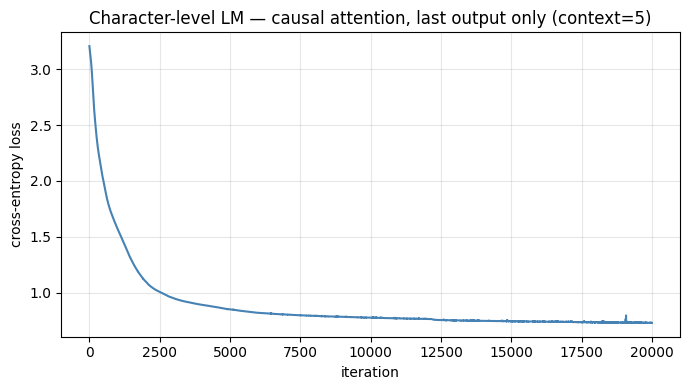

test accuracy: 0.163   (random baseline: 0.043)


In [65]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — causal attention, last output only (context=5)',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [66]:
def generate_last(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_last('it wa', n_chars=300))

it was th whor ofofdmrmrmrir iter w se inoee ofh oe of wo incsre he rorfofr isdonke withng inyst wehor wites awe it asd t whess he rofofrepsaitttttwwwgmrdrlity imee ithnorws o ofof doc oc of ofeigowsnbwelititisse peashe inonevyhs usrm vhoydlityase heposs d e hade it bod oc ir htof t thepep peshep it was 


---
---

## Step 15: Positional Embeddings

There is a subtle problem with the model in step 14. The token embedding table **E** maps each character to a vector based solely on its identity — the letter 't' always produces the same embedding regardless of whether it appears at position 1, 3, or 5. This means the attention mechanism has no way to distinguish *where* in the sequence a token appears. If you shuffled the input tokens, the model would produce the same output.

**Positional embeddings** fix this by adding a learned position vector to each token embedding:

$$\mathbf{e}_t' = \mathbf{e}_t + \mathbf{p}_t \qquad (1 \times 4) + (1 \times 4) = (1 \times 4)$$

where $\mathbf{p}_t$ is the $t$-th row of a learned position table $\mathbf{P} \in \mathbb{R}^{T \times d_e}$. Each position gets its own dense vector, trained alongside the rest of the network.

The combined embedding $\mathbf{e}_t'$ carries both *what* the token is and *where* it sits in the sequence. Everything downstream — Q, K, V projections, attention scores, the hidden layer — is unchanged. This is a single extra `nn.Embedding(context_len, embed_dim)` and one addition in the forward pass.

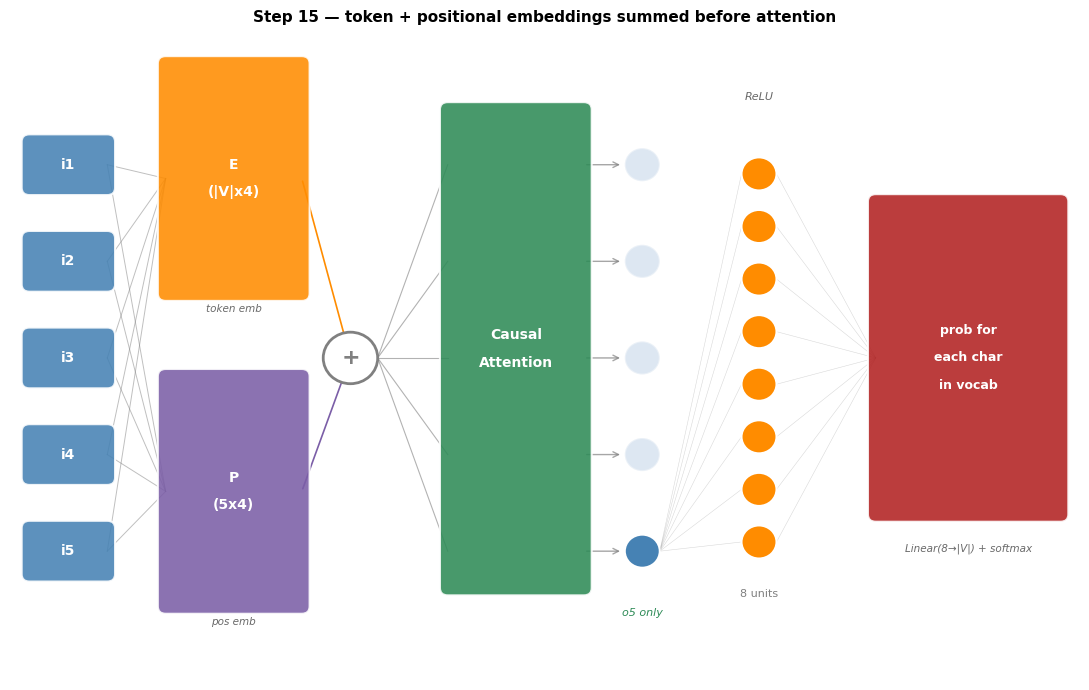

In [67]:
diagrams.step15()

In [68]:
class PosEmbLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_classes):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size,   embed_dim)   # token embeddings
        self.pos_emb = nn.Embedding(context_len,  embed_dim)   # positional embeddings
        self.W_Q     = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K     = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V     = nn.Linear(embed_dim, embed_dim, bias=False)
        self.fc1     = nn.Linear(embed_dim, 8)
        self.fc2     = nn.Linear(8, n_classes)

        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask', mask)

        positions = torch.arange(context_len)
        self.register_buffer('positions', positions)

    def forward(self, x):
        # token + positional embeddings  →  (batch, T, embed_dim)
        e = self.tok_emb(x) + self.pos_emb(self.positions)

        Q, K, V = self.W_Q(e), self.W_K(e), self.W_V(e)
        A       = (Q @ K.transpose(-2, -1)) / Q.shape[-1] ** 0.5 + self.mask
        O       = torch.softmax(A, dim=-1) @ V       # (batch, T, embed_dim)
        x       = torch.relu(self.fc1(O[:, -1, :]))  # last position only
        return self.fc2(x)


EMBED_DIM   = 4
CONTEXT_LEN = 5
model       = PosEmbLM(V_CHAR, EMBED_DIM, CONTEXT_LEN, n_classes=V_CHAR)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')
print(f'token emb:    {V_CHAR} x {EMBED_DIM} = {V_CHAR * EMBED_DIM} params')
print(f'position emb: {CONTEXT_LEN} x {EMBED_DIM} = {CONTEXT_LEN * EMBED_DIM} params')

total parameters: 407
token emb:    23 x 4 = 92 params
position emb: 5 x 4 = 20 params


In [69]:
MAX_ITER  = 20000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.4869


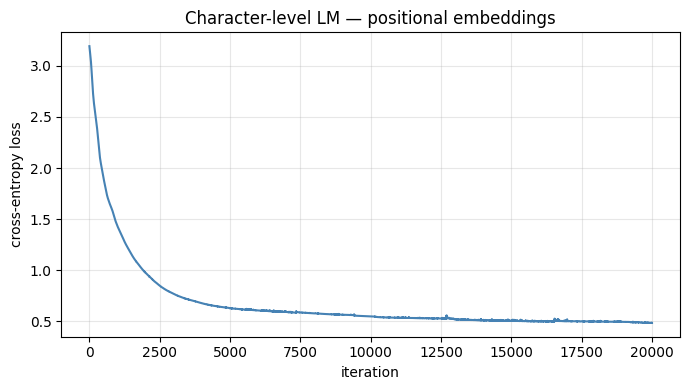

test accuracy: 0.275   (random baseline: 0.043)


In [70]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — positional embeddings',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [71]:
def generate_pos(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_pos('it wa', n_chars=300))

it was the oue of lighte iof bimss of foolishnfppaib of wisdom onh enets it hothiit b inc of dasv it t incsedypvity othn it t on wbflimhmps bpeeyplityr imm e onh of bims it was the egdespeeyehimm b ugeof inc agd nvsryyyinimm it lity it feyehimm it was the nge npeingr of dimps it was the sesyahimm it was 


---
---

## Step 16: Multi-Head Self-Attention

In step 15 we had a single attention head — one set of $\mathbf{W}_Q$, $\mathbf{W}_K$, $\mathbf{W}_V$ producing one attention pattern. The limitation is that a single head can only learn one way to route information across positions at a time.

**Multi-head attention** runs several attention heads in parallel, each with its own projection matrices, then concatenates their outputs:

$$\text{head}_h = \mathrm{softmax}\!\left(\frac{\mathbf{Q}_h\mathbf{K}_h^\top}{\sqrt{d_k}}\right)\mathbf{V}_h \qquad h = 1, \ldots, H$$

$$\mathbf{O} = [\text{head}_1 \,\|\, \text{head}_2 \,\|\, \cdots \,\|\, \text{head}_H] \, \mathbf{W}_O$$

where $\mathbf{W}_O$ is a learned output projection that mixes the heads back together.

### Dimensions with 2 heads

We use $H = 2$ heads and split the embedding dimension evenly, so each head operates in a $d_k = d_e / H = 4 / 2 = 2$ dimensional space:

$$\mathbf{Q}_h, \mathbf{K}_h, \mathbf{V}_h \in \mathbb{R}^{T \times 2} \qquad \text{head}_h \in \mathbb{R}^{T \times 2}$$

After concatenating both heads: $[\text{head}_1 \| \text{head}_2] \in \mathbb{R}^{T \times 4}$ — the same shape as a single-head output. The output projection $\mathbf{W}_O \in \mathbb{R}^{4 \times 4}$ maps back to $d_e = 4$.

This means the total parameter count for the attention layer is the same as two independent single-head layers — we are not adding capacity, we are splitting the existing capacity across two heads that can specialise independently. Everything downstream is unchanged.

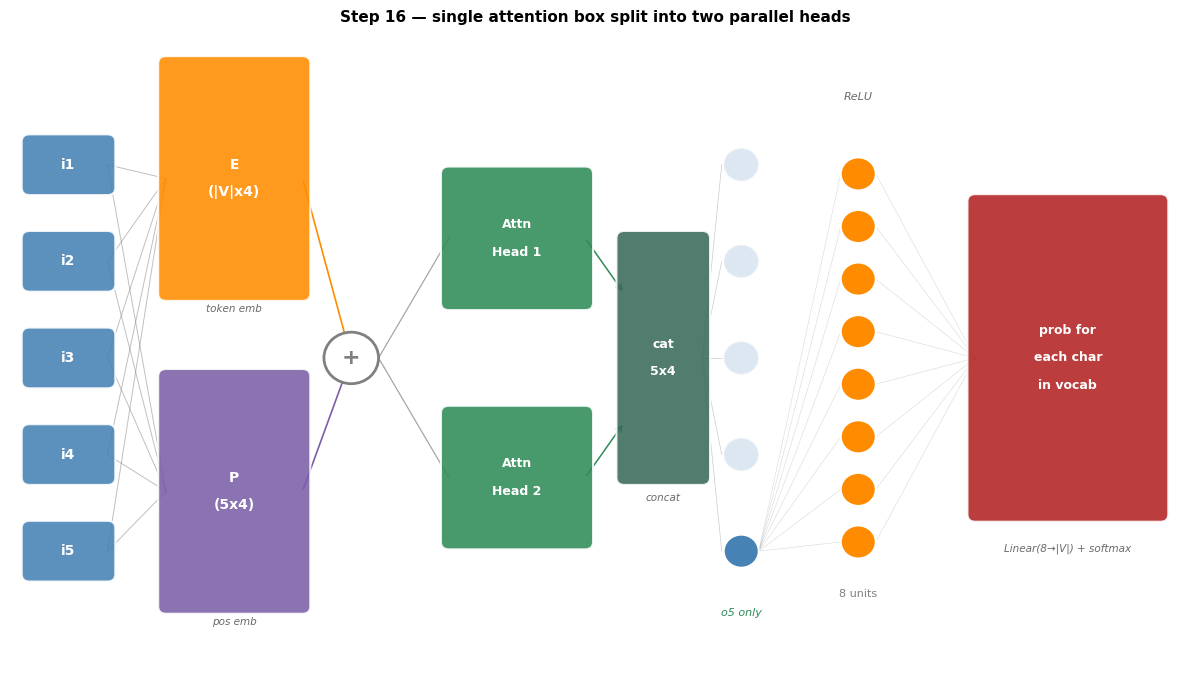

In [72]:
diagrams.step16()

In [73]:
class MultiHeadLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_heads, n_classes):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads  = n_heads
        self.d_k      = embed_dim // n_heads

        self.tok_emb  = nn.Embedding(vocab_size,  embed_dim)
        self.pos_emb  = nn.Embedding(context_len, embed_dim)
        self.W_Q      = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K      = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V      = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O      = nn.Linear(embed_dim, embed_dim, bias=False)
        self.fc1      = nn.Linear(embed_dim, 8)
        self.fc2      = nn.Linear(8, n_classes)

        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask',      mask)
        self.register_buffer('positions', torch.arange(context_len))

    def forward(self, x):
        B, T   = x.shape
        e      = self.tok_emb(x) + self.pos_emb(self.positions)  # (B, T, d_e)

        Q = self.W_Q(e)   # (B, T, d_e)
        K = self.W_K(e)
        V = self.W_V(e)

        # split into heads  →  (B, n_heads, T, d_k)
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

        # scaled dot-product attention per head
        A     = (Q @ K.transpose(-2, -1)) / self.d_k ** 0.5 + self.mask
        alpha = torch.softmax(A, dim=-1)
        O     = alpha @ V                                    # (B, n_heads, T, d_k)

        # concat heads  →  (B, T, d_e)  then output projection
        O = O.transpose(1, 2).contiguous().view(B, T, -1)
        O = self.W_O(O)

        x = torch.relu(self.fc1(O[:, -1, :]))               # last position only
        return self.fc2(x)


EMBED_DIM   = 4
CONTEXT_LEN = 5
N_HEADS     = 2
model       = MultiHeadLM(V_CHAR, EMBED_DIM, CONTEXT_LEN, N_HEADS, n_classes=V_CHAR)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'heads: {N_HEADS}   d_k per head: {EMBED_DIM // N_HEADS}   total parameters: {n_params}')

heads: 2   d_k per head: 2   total parameters: 423


In [74]:
MAX_ITER  = 20000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.6248


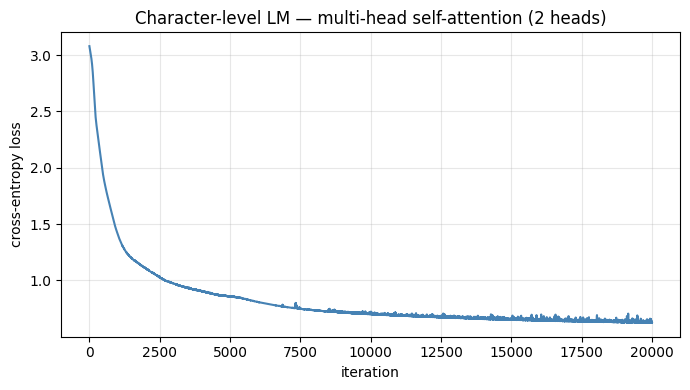

test accuracy: 0.100   (random baseline: 0.043)


In [75]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — multi-head self-attention (2 heads)',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [76]:
def generate_multihead(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_multihead('it wa', n_chars=300))

it was the spring i tnasf   iaiewwetliefgisiwei  m p swiof iaigge  as the easastwe heaiewior uuecwor uh w cwpes iofeiw owsshofsieiisdyheofihdcftehwpoasiwei eiagtne ccarw nisiomsfw odccwwfpnh rdp tti hiassiie wttyniiuohstw odccwwfpas ni hdasas w  iliefieiuna  ntpgmdiof deppastwe hseetolieiuasaswet asineic


---
---

## Step 17: Residual Connections + Layer Norm (Transformer Block)

In step 16 the attention output flows directly into the hidden layer. As we add more depth this causes two problems: gradients shrink as they propagate back through every transformation, and activations drift in scale making training unstable.

Two additions fix this and together define a **transformer block**.

### Residual connection

Instead of replacing the input with the attention output, we *add* them:

$$\mathbf{x} \leftarrow \mathbf{x} + \text{Attention}(\mathbf{x})$$

This gives gradients a direct path back through the network — they can skip over the attention computation entirely and flow straight to the embedding layer. Without this, deep networks are very difficult to train.

### Layer normalisation

Layer norm normalises each position vector independently to zero mean and unit variance, then applies a learned scale and shift:

$$\text{LayerNorm}(\mathbf{x}) = \gamma \cdot \frac{\mathbf{x} - \mu}{\sigma} + \beta$$

where $\mu$ and $\sigma$ are computed across the feature dimension for each position, and $\gamma$, $\beta$ are learned parameters. This keeps activations in a stable range regardless of how many layers they have passed through.

### The transformer block

Applied together, the pattern is:

$$\mathbf{x} \leftarrow \text{LayerNorm}(\mathbf{x} + \text{MultiHeadAttention}(\mathbf{x}))$$

This is one transformer block — the repeating unit of GPT. In step 18 we will stack several of these blocks on top of each other. Everything else — embeddings, positional encoding, the final linear layer — stays the same.

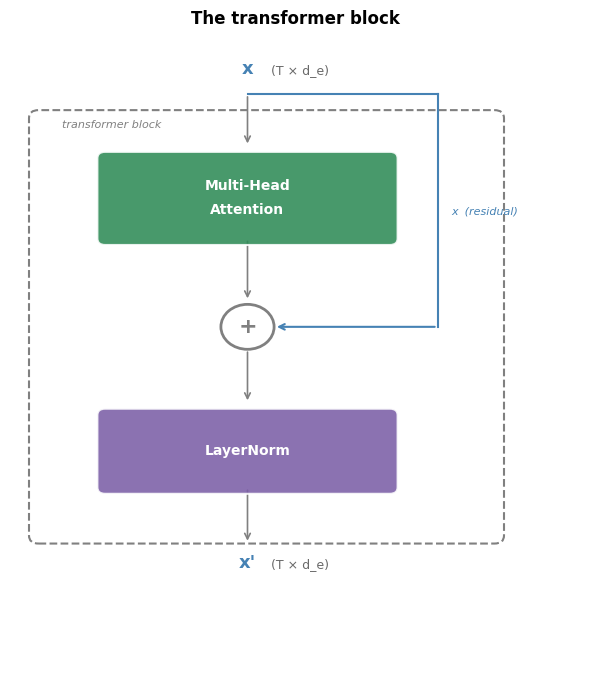

In [77]:
diagrams.step17_block()

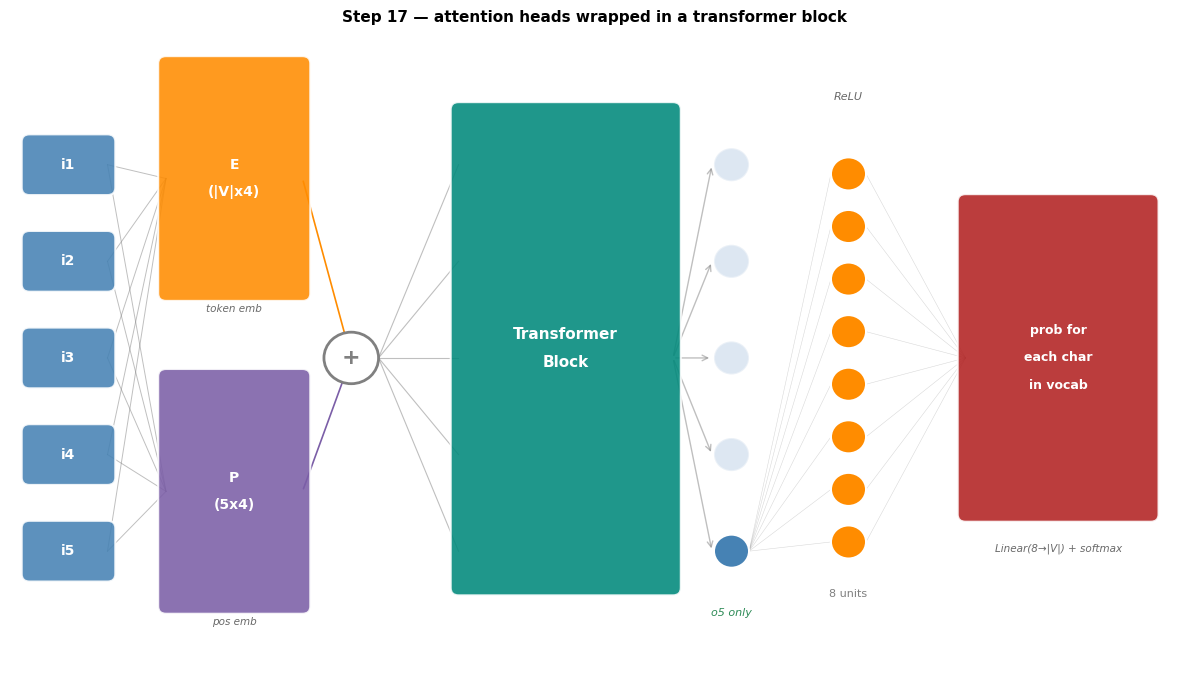

In [78]:
diagrams.step17_arch()

In [79]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, context_len):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = embed_dim // n_heads

        self.W_Q  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.norm = nn.LayerNorm(embed_dim)

        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, _ = x.shape

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # split into heads  →  (B, n_heads, T, d_k)
        def split(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = split(Q), split(K), split(V)
        A       = (Q @ K.transpose(-2, -1)) / self.d_k ** 0.5 + self.mask
        O       = torch.softmax(A, dim=-1) @ V           # (B, n_heads, T, d_k)
        O       = O.transpose(1, 2).contiguous().view(B, T, -1)
        O       = self.W_O(O)

        return self.norm(x + O)                          # residual + layer norm


class TransformerLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_heads, n_classes):
        super().__init__()
        self.tok_emb   = nn.Embedding(vocab_size,  embed_dim)
        self.pos_emb   = nn.Embedding(context_len, embed_dim)
        self.block     = TransformerBlock(embed_dim, n_heads, context_len)
        self.fc1       = nn.Linear(embed_dim, 8)
        self.fc2       = nn.Linear(8, n_classes)
        self.register_buffer('positions', torch.arange(context_len))

    def forward(self, x):
        e = self.tok_emb(x) + self.pos_emb(self.positions)  # (B, T, d_e)
        e = self.block(e)                                    # (B, T, d_e)
        x = torch.relu(self.fc1(e[:, -1, :]))               # last position only
        return self.fc2(x)


EMBED_DIM   = 4
CONTEXT_LEN = 5
N_HEADS     = 2
model       = TransformerLM(V_CHAR, EMBED_DIM, CONTEXT_LEN, N_HEADS, n_classes=V_CHAR)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {n_params}')

total parameters: 431


In [80]:
MAX_ITER  = 25000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.2961


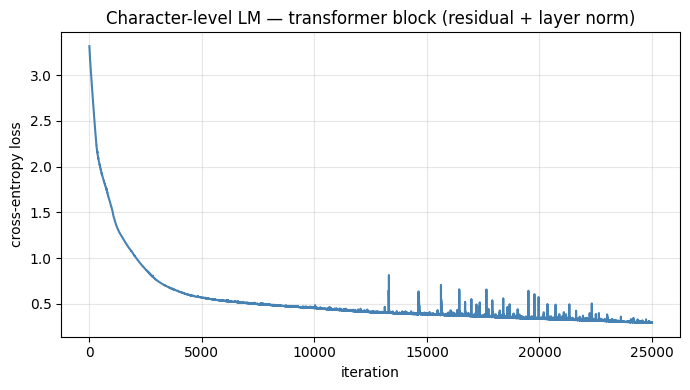

test accuracy: 0.263   (random baseline: 0.043)


In [81]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title='Character-level LM — transformer block (residual + layer norm)',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [82]:
def generate_transformer(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_transformer('it wa', n_chars=300))

it was the wimef of desmig besmit of tithogepg witherire urfrges of hoolisse it was the age of foolief of desn of litymes of hon bithef of darknnns imust of tinawunir uchie of wigyage uf ggufhe of wit was the seasae winng of hodaor fyagases imait was the sprorasagedes ice of foolief it was the sesn imuf 


---
---

## Step 18: Stacked Transformer Blocks — Small GPT

In step 17 we had a single transformer block. GPT stacks $N$ identical blocks on top of each other, passing the full $(T \times d_e)$ output of each block as the input to the next:

$$\mathbf{x}^{(0)} = \text{TokenEmb} + \text{PosEmb}$$

$$\mathbf{x}^{(l)} = \text{TransformerBlock}_l(\mathbf{x}^{(l-1)}) \qquad l = 1, \ldots, N$$

$$\hat{\mathbf{y}} = \text{Linear}(\mathbf{x}^{(N)}_{T})$$

Each block receives the full $(T \times d_e)$ sequence and outputs the same shape. Only after the final block do we take the last position vector $\mathbf{x}^{(N)}_T$ and pass it to the classifier.

Each layer builds increasingly abstract representations. Early blocks tend to learn local patterns — which characters commonly follow which — while deeper blocks can capture longer-range structure. This is the same phenomenon seen in deep vision networks, just applied to sequences.

We use $N = 2$ blocks here to keep the model small and trainable on CPU. GPT-2 uses 12 to 48 blocks with much larger $d_e$ and more heads — but the architecture is identical to what we have here.

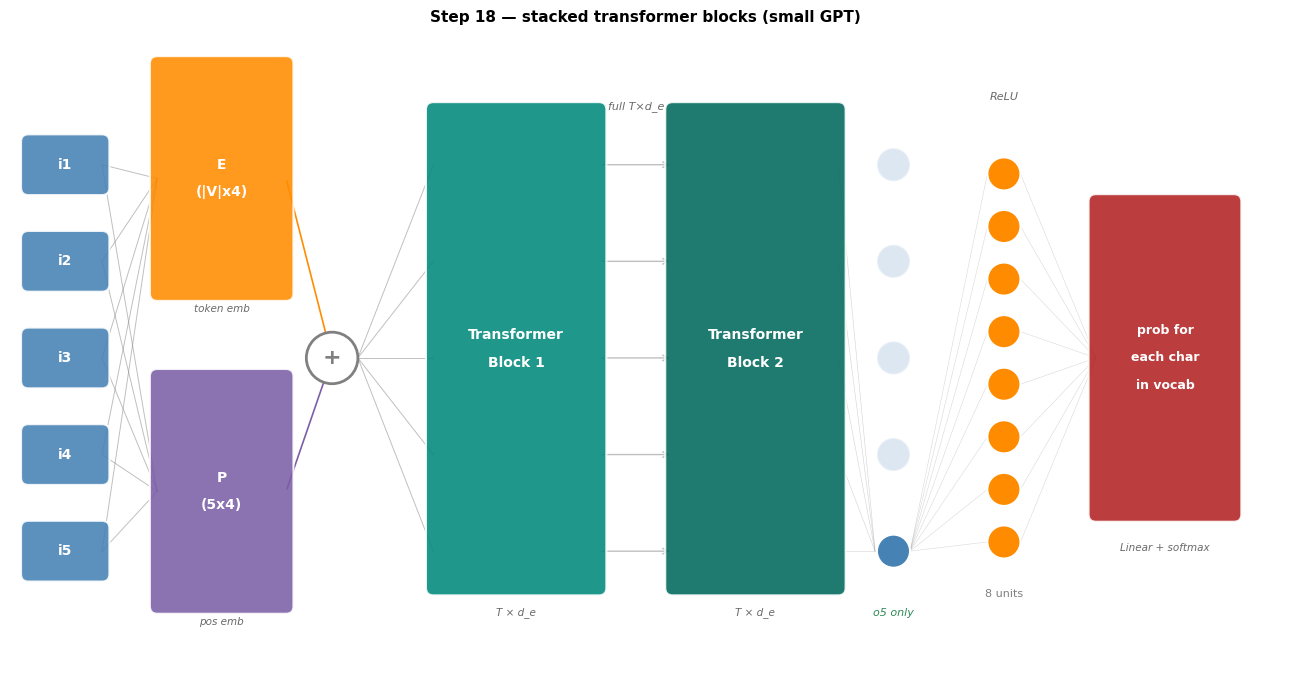

In [83]:
diagrams.step18()

In [84]:
class SmallGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, context_len, n_heads, n_layers, n_classes):
        super().__init__()
        self.tok_emb  = nn.Embedding(vocab_size,  embed_dim)
        self.pos_emb  = nn.Embedding(context_len, embed_dim)
        self.blocks   = nn.Sequential(*[
            TransformerBlock(embed_dim, n_heads, context_len)
            for _ in range(n_layers)
        ])
        self.fc1      = nn.Linear(embed_dim, 8)
        self.fc2      = nn.Linear(8, n_classes)
        self.register_buffer('positions', torch.arange(context_len))

    def forward(self, x):
        e = self.tok_emb(x) + self.pos_emb(self.positions)  # (B, T, d_e)
        e = self.blocks(e)                                   # (B, T, d_e) through N blocks
        x = torch.relu(self.fc1(e[:, -1, :]))               # last position only
        return self.fc2(x)


EMBED_DIM   = 4
CONTEXT_LEN = 5
N_HEADS     = 2
N_LAYERS    = 2
model       = SmallGPT(V_CHAR, EMBED_DIM, CONTEXT_LEN, N_HEADS, N_LAYERS, n_classes=V_CHAR)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'layers: {N_LAYERS}   heads: {N_HEADS}   d_e: {EMBED_DIM}   total parameters: {n_params}')

layers: 2   heads: 2   d_e: 4   total parameters: 503


In [85]:
MAX_ITER  = 25000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.0946


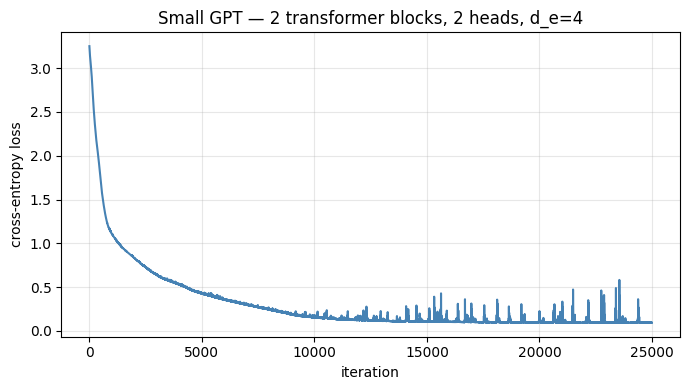

test accuracy: 0.175   (random baseline: 0.043)


In [86]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title=f'Small GPT — {N_LAYERS} transformer blocks, {N_HEADS} heads, d_e={EMBED_DIM}',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [87]:
def generate_gpt(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_gpt('it wa', n_chars=300))

it was the epoch of belias otcinih to g mo w thesliiinteingfioagiesoctcsinyoihte i ioihr we had as meinrnnigi h hoa seoheesiiigf i of hope it was the season of light it was the best of times it was the season of despair we had everything before us we had nothing before us we had as meinrnnigi odhoedees w


---
---

## Step 19: Feed-Forward Sublayer Inside the Transformer Block

In steps 17 and 18 the transformer block contained only the attention sublayer. In real GPT each block has a second sublayer: a **position-wise feed-forward network** applied independently to each position after the attention:

$$\text{FFN}(\mathbf{x}) = \mathbf{W}_2 \, \text{GELU}(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$$

It expands the representation to a higher dimension, applies a nonlinearity, then projects back:

$$\mathbf{x} \in \mathbb{R}^{d_e} \xrightarrow{\mathbf{W}_1} \mathbb{R}^{4 d_e} \xrightarrow{\text{GELU}} \mathbb{R}^{4 d_e} \xrightarrow{\mathbf{W}_2} \mathbb{R}^{d_e}$$

GPT conventionally expands by a factor of 4, so with $d_e = 4$ the hidden dimension is 16.

We also switch from ReLU to **GELU** (Gaussian Error Linear Unit), which is smooth rather than piecewise linear and works better in practice for transformers.

The full transformer block now has two sublayers, each with its own residual connection and layer norm:

$$\mathbf{x} \leftarrow \text{LayerNorm}(\mathbf{x} + \text{MHA}(\mathbf{x}))$$

$$\mathbf{x} \leftarrow \text{LayerNorm}(\mathbf{x} + \text{FFN}(\mathbf{x}))$$

The external `fc1/fc2` classifier layers from previous steps are removed — the output of the last block's FFN goes directly to a linear layer over the vocabulary.

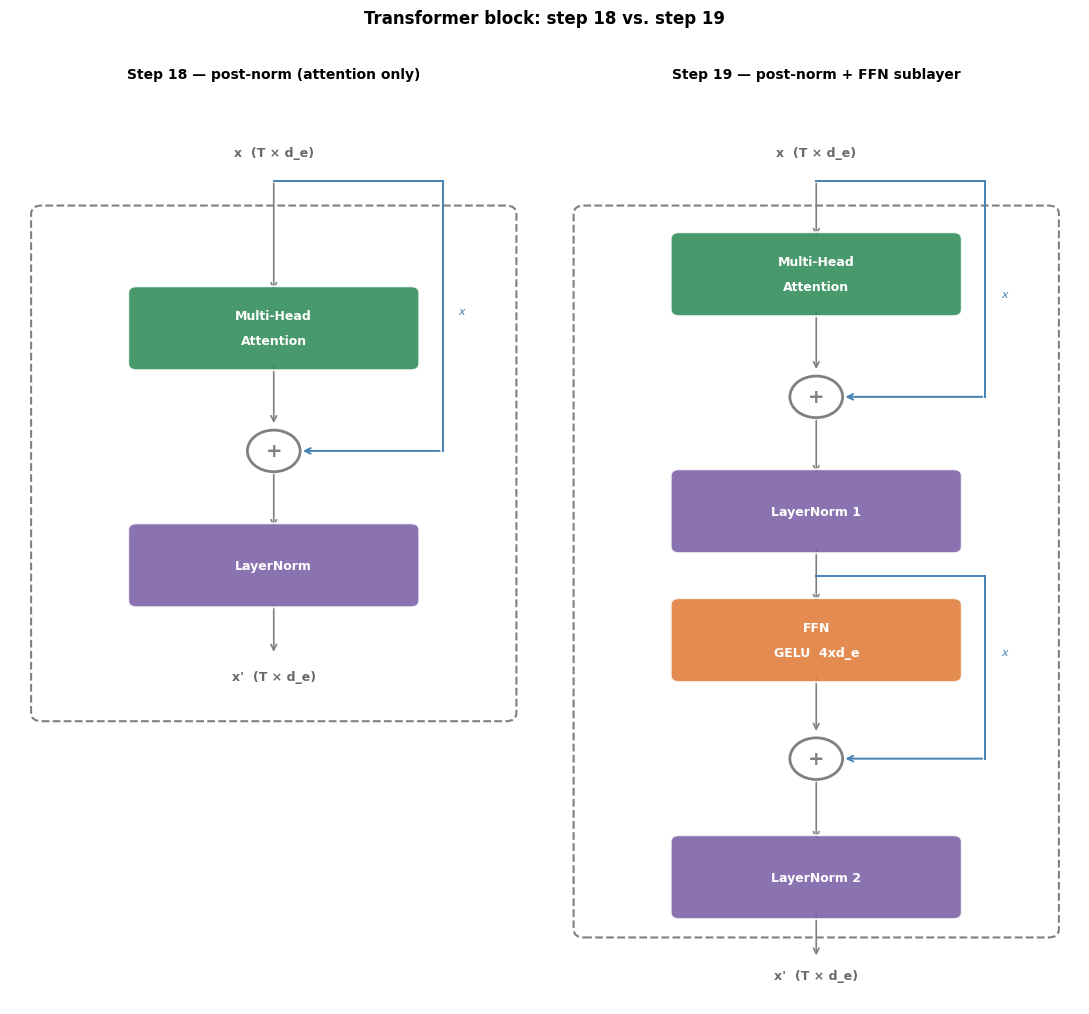

In [88]:
diagrams.step19_block()

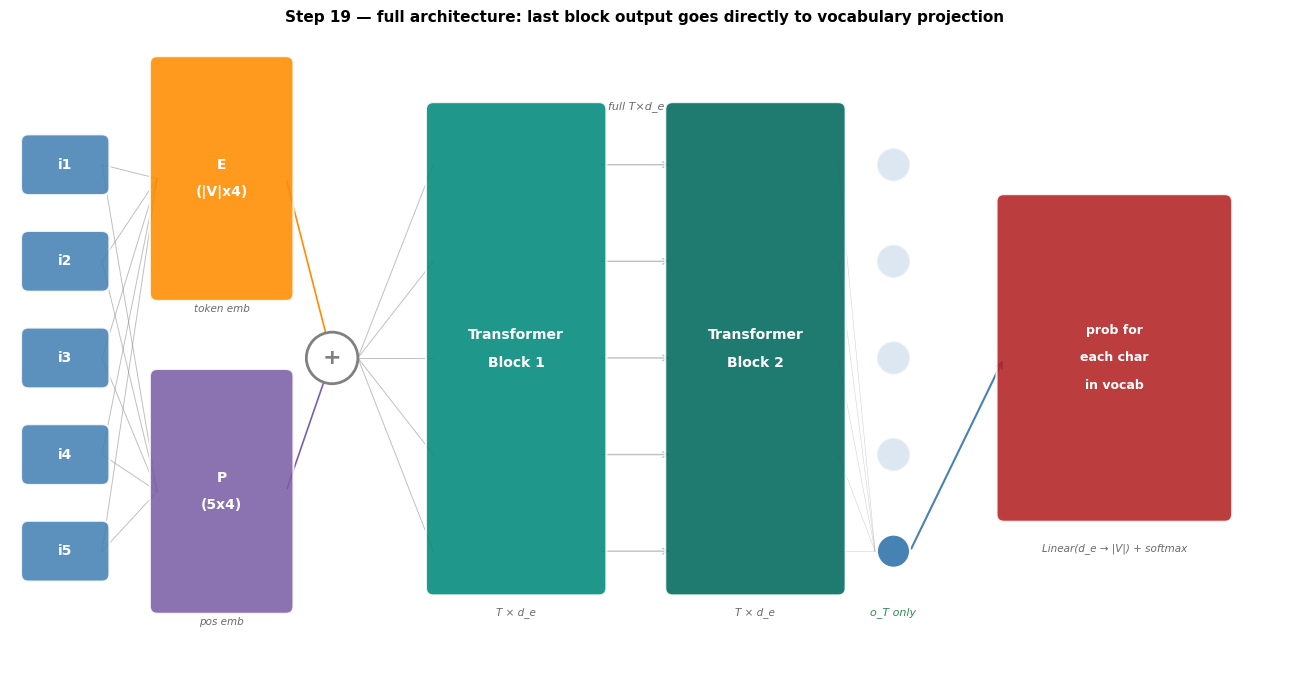

In [89]:
diagrams.step19_arch()

In [90]:
class TransformerBlockFFN(nn.Module):
    """Post-norm transformer block with attention + FFN sublayers."""

    def __init__(self, embed_dim, n_heads, context_len, ff_mult=4):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = embed_dim // n_heads

        # attention sublayer
        self.W_Q   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.norm1 = nn.LayerNorm(embed_dim)

        # feed-forward sublayer: expand → GELU → project back
        self.ff    = nn.Sequential(
                         nn.Linear(embed_dim, ff_mult * embed_dim),
                         nn.GELU(),
                         nn.Linear(ff_mult * embed_dim, embed_dim),
                     )
        self.norm2 = nn.LayerNorm(embed_dim)

        mask = torch.full((context_len, context_len), float('-inf'))
        mask = torch.triu(mask, diagonal=1)
        self.register_buffer('mask', mask)

    def attention(self, x):
        B, T, _ = x.shape
        Q, K, V = self.W_Q(x), self.W_K(x), self.W_V(x)

        def split(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = split(Q), split(K), split(V)
        A       = (Q @ K.transpose(-2, -1)) / self.d_k ** 0.5 + self.mask
        O       = torch.softmax(A, dim=-1) @ V
        O       = O.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_O(O)

    def forward(self, x):
        x = self.norm1(x + self.attention(x))   # attention sublayer + residual + norm
        x = self.norm2(x + self.ff(x))          # FFN sublayer + residual + norm
        return x


class SmallGPTFFN(nn.Module):
    """Small GPT with FFN sublayer inside each transformer block."""

    def __init__(self, vocab_size, embed_dim, context_len, n_heads, n_layers):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size,  embed_dim)
        self.pos_emb = nn.Embedding(context_len, embed_dim)
        self.blocks  = nn.Sequential(*[
            TransformerBlockFFN(embed_dim, n_heads, context_len)
            for _ in range(n_layers)
        ])
        # the FFN sublayer inside the last block replaces the external fc1/fc2 —
        # output of the last block goes directly to the vocabulary projection
        self.lm_head = nn.Linear(embed_dim, vocab_size)
        self.register_buffer('positions', torch.arange(context_len))

    def forward(self, x):
        e = self.tok_emb(x) + self.pos_emb(self.positions)   # (B, T, d_e)
        e = self.blocks(e)                                    # (B, T, d_e)
        return self.lm_head(e[:, -1, :])                      # last position → logits


EMBED_DIM   = 4
CONTEXT_LEN = 5
N_HEADS     = 2
N_LAYERS    = 2
model       = SmallGPTFFN(V_CHAR, EMBED_DIM, CONTEXT_LEN, N_HEADS, N_LAYERS)
criterion   = nn.CrossEntropyLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'layers: {N_LAYERS}   heads: {N_HEADS}   d_e: {EMBED_DIM}   '
      f'FFN hidden: {4 * EMBED_DIM}   total params: {n_params}')

layers: 2   heads: 2   d_e: 4   FFN hidden: 16   total params: 683


In [91]:
MAX_ITER  = 25000
loss_hist = []

for t in range(MAX_ITER):
    logits = model(X_t)
    loss   = criterion(logits, y_t)
    loss_hist.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

print(f'final loss: {loss_hist[-1]:.4f}')

final loss: 0.4098


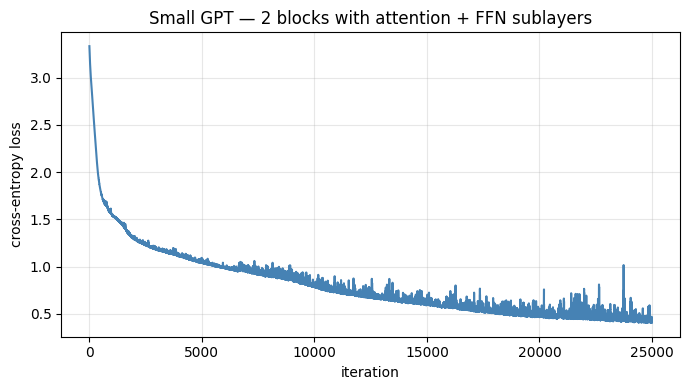

test accuracy: 0.200   (random baseline: 0.043)


In [92]:
with torch.no_grad():
    y_pred = model(X_tt).argmax(dim=1).numpy()
plots.convergence(loss_hist,
                  title=f'Small GPT — {N_LAYERS} blocks with attention + FFN sublayers',
                  vocab_size=V_CHAR, y_test=y_test_lm, y_pred=y_pred)

In [93]:
def generate_ffn(seed, n_chars=300):
    assert len(seed) >= CONTEXT_LEN
    result = list(seed)
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx   = torch.tensor([[ch2idx[c] for c in result[-CONTEXT_LEN:]]],
                                  dtype=torch.long)
            probs = torch.softmax(model(ctx).squeeze(), dim=0).numpy()
            result.append(idx2ch[np.random.choice(V_CHAR, p=probs)])
    return ''.join(result)

print(generate_ffn('it wa', n_chars=300))

it was the epte  ihbege ieb worhhasos osnreiooficege te  sbct hy hrrasit srioesbebp pi is re hh tn ho ltwfewwtomt isihe owt roe heb rh nm hfisrcfp f  oaipsce om ooiascoootdias oleie coins n ips uwe ooartofldtig ieopb  nioiat  ooom fcooresase ushs ystrraiyrbite re tn im inegstc ts eb tt sbilii oo iseioebb


---
---
## Step 20: Scaled-Up GPT on Mac GPU (MPS)

Up to this point we have been running tiny models on a small text passage — enough to demonstrate the architecture, but not enough to generate convincing text. The architecture in step 19 is structurally identical to GPT-2; the only difference is scale.

This step scales up three things at once:

- **More data** — we download **Tiny Shakespeare** (~1 MB, the complete works of Shakespeare in plain text), which is the standard benchmark for character-level language modelling and large enough that the model has to genuinely generalise rather than memorise.
- **Larger model** — we bump $d_e$, the number of heads, the number of layers, and the context length to GPT-2-like ratios (just smaller in absolute terms):
  - $d_e = 64$, heads = 4, layers = 4, context = 64
- **GPU acceleration** — Apple Silicon Macs have a Metal-backed GPU that PyTorch exposes through the `mps` device. We move the model and tensors to `mps` so training runs an order of magnitude faster than on CPU.

### Using the MPS backend

```python
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model  = model.to(device)
X_t    = X_t.to(device)
```

MPS supports most PyTorch operations transparently — the only change in our code is calling `.to(device)` on the model and the tensors. Everything else is identical.

### Mini-batched training

Until now every training step has computed the gradient over the **entire training set** in a single forward and backward pass. That worked because the dataset was tiny — a few hundred examples. Tiny Shakespeare gives us roughly a million examples, which is far too many to fit through the model at once on any device.

The fix is **mini-batch stochastic gradient descent**. At each step we sample a small random subset of the training set — a **batch** of size $B$ (we use 64) — and compute the gradient on just that batch:

$$\hat{\nabla}\mathcal{L} = \frac{1}{B}\sum_{i \in \text{batch}} \nabla \ell_i$$

This is a noisy but unbiased estimate of the true gradient over the full dataset. Each step costs $O(B)$ instead of $O(N)$, so we can take many more optimisation steps in the same amount of time. The added gradient noise turns out to be beneficial — it helps the optimiser escape sharp local minima and tends to find flatter, better-generalising solutions.

Every modern deep learning system trains this way. "Batch size" is one of the most-tuned hyperparameters in practice. We sample batches with replacement here for simplicity; production systems typically iterate through shuffled mini-batches in **epochs**.

### Early stopping

With a model this large relative to a fixed dataset, training will eventually overfit — the training loss keeps falling while the test loss starts to rise. Rather than choose a magic `MAX_ITER` value, we use **early stopping**: we evaluate test loss every 200 batches and halt training when test loss fails to improve for 5 consecutive evaluations.

### What changes vs. step 19

Nothing structural. Same `TransformerBlockFFN`, same `SmallGPTFFN`, same loss. The differences are:

1. Larger hyperparameter values
2. Tiny Shakespeare instead of a hand-typed passage
3. `.to(device)` calls to put everything on the GPU
4. Mini-batched training
5. Early stopping driven by test loss

In [94]:
# detect Mac GPU (MPS) with fallback to CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using device: {device}')

# download Tiny Shakespeare (~1 MB) once and cache locally
SHAKESPEARE_URL = ('https://raw.githubusercontent.com/karpathy/char-rnn/'
                   'master/data/tinyshakespeare/input.txt')
CACHE_PATH      = 'tinyshakespeare.txt'

if not os.path.exists(CACHE_PATH):
    print('downloading Tiny Shakespeare...')
    urllib.request.urlretrieve(SHAKESPEARE_URL, CACHE_PATH)

with open(CACHE_PATH, 'r') as f:
    text_big = f.read().lower()

print(f'corpus length: {len(text_big):,} characters')

# build vocabulary
vocab_big  = sorted(set(text_big))
V_BIG      = len(vocab_big)
ch2idx_big = {c: i for i, c in enumerate(vocab_big)}
idx2ch_big = {i: c for c, i in ch2idx_big.items()}
print(f'vocabulary size: {V_BIG}  ({repr("".join(vocab_big))})')

# sliding window dataset
CONTEXT_LEN_BIG = 64
ids = np.array([ch2idx_big[c] for c in text_big], dtype=np.int64)
X_big = np.stack([ids[i:i + CONTEXT_LEN_BIG] for i in range(len(ids) - CONTEXT_LEN_BIG)])
y_big = ids[CONTEXT_LEN_BIG:]

split = int(0.9 * len(X_big))
X_train_big = torch.tensor(X_big[:split], dtype=torch.long).to(device)
y_train_big = torch.tensor(y_big[:split], dtype=torch.long).to(device)
X_test_big  = torch.tensor(X_big[split:], dtype=torch.long).to(device)
y_test_big  = torch.tensor(y_big[split:], dtype=torch.long).to(device)

print(f'context length: {CONTEXT_LEN_BIG}   train: {len(X_train_big):,}   test: {len(X_test_big):,}')

using device: mps
corpus length: 1,115,394 characters
vocabulary size: 39  ("\n !$&',-.3:;?abcdefghijklmnopqrstuvwxyz")
context length: 64   train: 1,003,797   test: 111,533


In [95]:
# scaled-up GPT, identical architecture to step 0
EMBED_DIM_BIG = 64
N_HEADS_BIG   = 4
N_LAYERS_BIG  = 4

model = SmallGPTFFN(V_BIG, EMBED_DIM_BIG, CONTEXT_LEN_BIG, N_HEADS_BIG, N_LAYERS_BIG).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

n_params = sum(p.numel() for p in model.parameters())
print(f'd_e: {EMBED_DIM_BIG}   heads: {N_HEADS_BIG}   layers: {N_LAYERS_BIG}   '
      f'context: {CONTEXT_LEN_BIG}')
print(f'total parameters: {n_params:,}')
print(f'device: {next(model.parameters()).device}')

d_e: 64   heads: 4   layers: 4   context: 64
total parameters: 208,039
device: mps:0


In [96]:
# mini-batched training with early stopping
BATCH_SIZE = 64
MAX_ITER   = 200000     # ceiling — early stopping usually halts before this
EVAL_EVERY = 2000

loss_hist        = []
test_hist        = []
n_train          = len(X_train_big)

for step in range(MAX_ITER):
    idx     = torch.randint(0, n_train, (BATCH_SIZE,), device=device)
    X_batch = X_train_big[idx]
    y_batch = y_train_big[idx]

    logits = model(X_batch)
    loss   = criterion(logits, y_batch)
    loss_hist.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (step + 1) % EVAL_EVERY == 0:
        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(X_test_big), y_test_big).item()
        test_hist.append((step + 1, test_loss))
        model.train()

        print(f'step {step+1:5d}   train loss {loss.item():.4f}   '
              f'test loss {test_loss:.4f}')

        

step  2000   train loss 2.5803   test loss 2.1969
step  4000   train loss 1.9020   test loss 2.0152
step  6000   train loss 2.0532   test loss 1.9383
step  8000   train loss 1.7967   test loss 1.8840
step 10000   train loss 1.6936   test loss 1.8656
step 12000   train loss 1.8151   test loss 1.8314
step 14000   train loss 1.5830   test loss 1.8115
step 16000   train loss 1.5984   test loss 1.7808
step 18000   train loss 1.4701   test loss 1.7639
step 20000   train loss 1.4131   test loss 1.7502
step 22000   train loss 1.6782   test loss 1.7276
step 24000   train loss 1.9727   test loss 1.7130
step 26000   train loss 1.6983   test loss 1.7056
step 28000   train loss 1.9996   test loss 1.6971
step 30000   train loss 1.5394   test loss 1.6765
step 32000   train loss 1.3650   test loss 1.6709
step 34000   train loss 1.7876   test loss 1.6532
step 36000   train loss 1.4755   test loss 1.6477
step 38000   train loss 1.7890   test loss 1.6375
step 40000   train loss 1.5550   test loss 1.6389


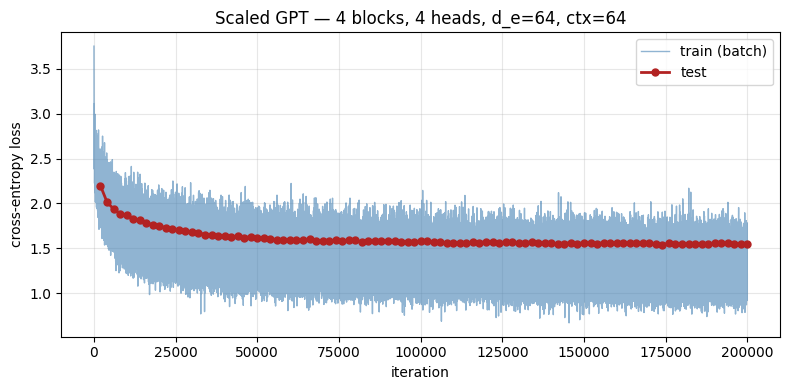

test accuracy: 0.536   (random baseline: 0.026)


In [99]:
plots.convergence_with_test(
    loss_hist, test_hist,
    title=f'Scaled GPT — {N_LAYERS_BIG} blocks, {N_HEADS_BIG} heads, '
          f'd_e={EMBED_DIM_BIG}, ctx={CONTEXT_LEN_BIG}',
)

model.eval()
with torch.no_grad():
    y_pred = model(X_test_big).argmax(dim=1)
    accuracy = (y_pred == y_test_big).float().mean().item()
print(f'test accuracy: {accuracy:.3f}   (random baseline: {1/V_BIG:.3f})')

In [100]:
def generate_big(seed, n_chars=500):
    assert len(seed) >= CONTEXT_LEN_BIG, f'seed must be at least {CONTEXT_LEN_BIG} chars'
    result = list(seed.lower())
    model.eval()
    with torch.no_grad():
        for _ in range(n_chars):
            ctx_ids = [ch2idx_big[c] for c in result[-CONTEXT_LEN_BIG:]]
            ctx     = torch.tensor([ctx_ids], dtype=torch.long, device=device)
            probs   = torch.softmax(model(ctx).squeeze(), dim=0).cpu().numpy()
            result.append(idx2ch_big[np.random.choice(V_BIG, p=probs)])
    return ''.join(result)

# seed must be at least CONTEXT_LEN_BIG chars long
seed = text_big[:CONTEXT_LEN_BIG]
print(generate_big(seed, n_chars=500))

first citizen:
before we proceed any further, hear me speak.

all toward:
promises, one shall loathing hortension
to such a shedful leaving him redmenced her
father'd richard.

flitting:
how prisoner, aumerle, like a richard,
impute to my sovereigns allies;
for head it.

mamillius:
he's concle, pob the deed, no.

fault to the quench this deed with blood not.

mamillius:
is captain violent to closed; i'll ten hot;
revent thou hate the way other rhoef.

gatesby:
nay, ignoral your own.

i joy:
why, what, ho! affected that fair lost
make my resolved. the noble l
